# Libraries and Dependancies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Expanded_data_with_more_features dataset

Data Dictionary (column description)
- Gender: Gender of the student (male/female)
- EthnicGroup: Ethnic group of the student (group A to E)
- ParentEduc: Parent(s) education background (from some_highschool to master's degree)
- LunchType: School lunch type (standard or free/reduced)
- TestPrep: Test preparation course followed (completed or none)
- ParentMaritalStatus: Parent(s) marital status (married/single/widowed/divorced)
- PracticeSport: How often the student parctice sport (never/sometimes/regularly))
- IsFirstChild: If the child is first child in the family or not (yes/no)
- NrSiblings: Number of siblings the student has (0 to 7)
- TransportMeans: Means of transport to school (schoolbus/private)
- WklyStudyHours: Weekly self-study hours(less that 5hrs; between 5 and 10hrs; more than 10hrs)
- MathScore: math test score(0-100)
- ReadingScore: reading test score(0-100)
- WritingScore: writing test score(0-100)

## Reading Data

In [2]:
data = pd.read_csv('/content/Expanded_data_with_more_features.csv')

data.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


## Exploratory Data Analysis (EDA)

In [3]:
data.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


In [5]:
data.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore
count,29069.000000,30641.000000,30641.000000,30641.000000
mean,2.145894,66.558402,69.377533,68.418622
std,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,10.000000,4.000000
25%,1.000000,56.000000,59.000000,58.000000
50%,2.000000,67.000000,70.000000,69.000000
75%,3.000000,78.000000,80.000000,79.000000
max,7.000000,100.000000,100.000000,100.000000


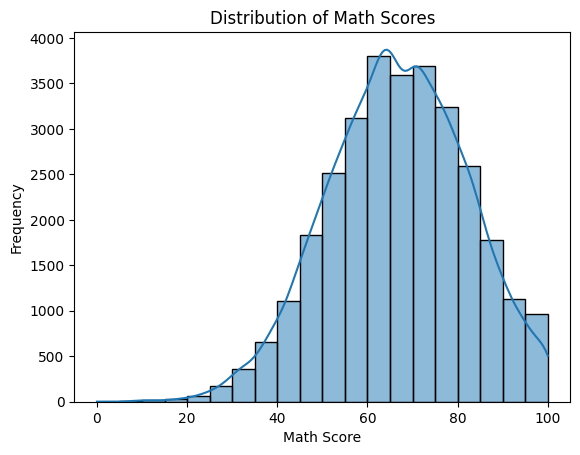

In [6]:
sns.histplot(data['MathScore'], kde=True, bins=20)
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.title("Distribution of Math Scores")
plt.show()

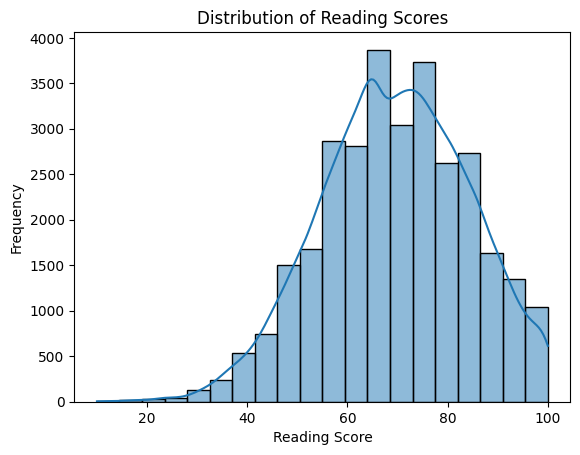

In [7]:
sns.histplot(data['ReadingScore'], kde=True, bins=20)
plt.xlabel("Reading Score")
plt.ylabel("Frequency")
plt.title("Distribution of Reading Scores")
plt.show()

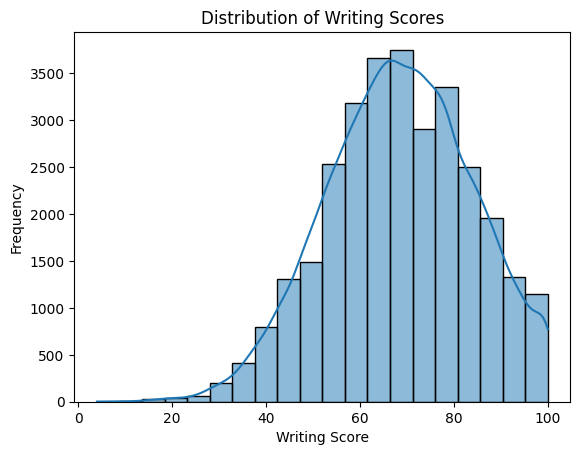

In [8]:
sns.histplot(data['WritingScore'], kde=True, bins=20)
plt.xlabel("Writing Score")
plt.ylabel("Frequency")
plt.title("Distribution of Writing Scores")
plt.show()

## Data Preprocessing

### Handling missing values

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


In [10]:
numerical_data = data.select_dtypes(['float64','int64'])
numerical_data.isnull().sum()

,0
NrSiblings,1572
MathScore,0
ReadingScore,0
WritingScore,0


In [11]:
categorical_data = data.select_dtypes(['object'])
categorical_data.isnull().sum()

,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
TransportMeans,3134
WklyStudyHours,955


In [12]:
numrical_imputer = SimpleImputer(strategy='mean')
categorical_imputer = SimpleImputer(strategy='most_frequent')

In [13]:
numerical_data = pd.DataFrame(numrical_imputer.fit_transform(numerical_data),
                              columns=numerical_data.columns)
categorical_data = pd.DataFrame(categorical_imputer.fit_transform(categorical_data),
                                columns=categorical_data.columns)

In [14]:
print(numerical_data.isnull().sum())
print("----"*20)
print(categorical_data.isnull().sum())

NrSiblings      0
MathScore       0
ReadingScore    0
WritingScore    0
dtype: int64
--------------------------------------------------------------------------------
Gender                 0
EthnicGroup            0
ParentEduc             0
LunchType              0
TestPrep               0
ParentMaritalStatus    0
PracticeSport          0
IsFirstChild           0
TransportMeans         0
WklyStudyHours         0
dtype: int64


In [15]:
numerical_data = numerical_data.astype('int64')

In [16]:
data[numerical_data.columns] = numerical_data
data[categorical_data.columns] = categorical_data

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               30641 non-null  object
 1   EthnicGroup          30641 non-null  object
 2   ParentEduc           30641 non-null  object
 3   LunchType            30641 non-null  object
 4   TestPrep             30641 non-null  object
 5   ParentMaritalStatus  30641 non-null  object
 6   PracticeSport        30641 non-null  object
 7   IsFirstChild         30641 non-null  object
 8   NrSiblings           30641 non-null  int64 
 9   TransportMeans       30641 non-null  object
 10  WklyStudyHours       30641 non-null  object
 11  MathScore            30641 non-null  int64 
 12  ReadingScore         30641 non-null  int64 
 13  WritingScore         30641 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 3.3+ MB


### Handling Duplicates

In [18]:
data.duplicated().sum()

np.int64(1)

In [19]:
# the data has no dulplicates

### Outlier Detection and Handling

In [20]:
numerical_data = data.select_dtypes(['int64'])
numerical_data.describe()

,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,30641.000000,30641.000000,30641.000000
mean,2.138409,66.558402,69.377533,68.418622
std,1.420707,15.361616,14.758952,15.443525
min,0.000000,0.000000,10.000000,4.000000
25%,1.000000,56.000000,59.000000,58.000000
50%,2.000000,67.000000,70.000000,69.000000
75%,3.000000,78.000000,80.000000,79.000000
max,7.000000,100.000000,100.000000,100.000000


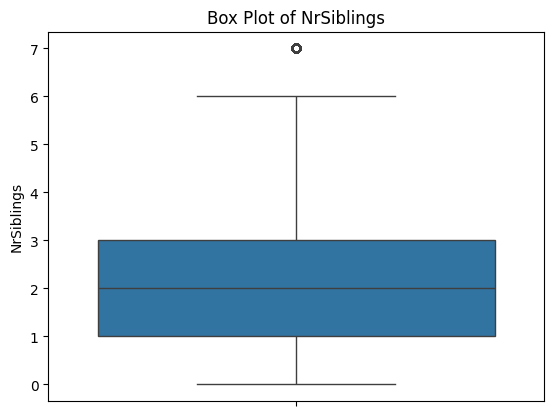

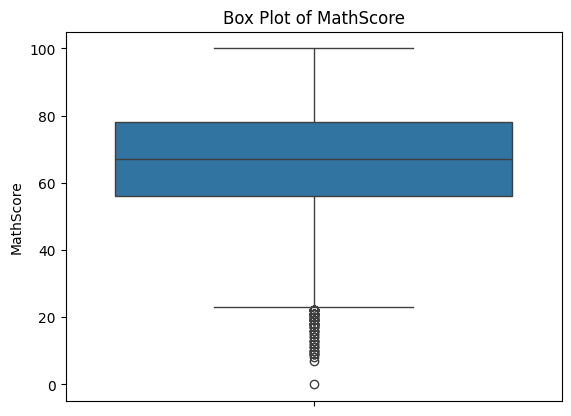

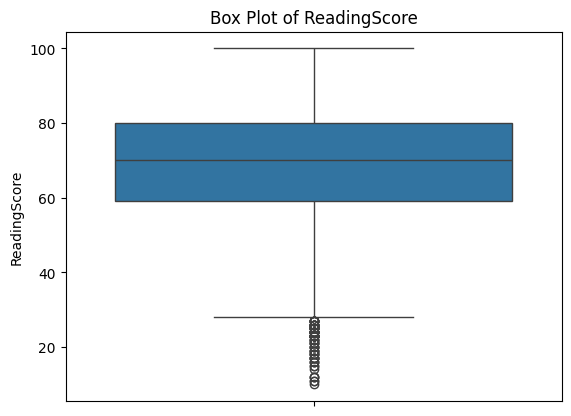

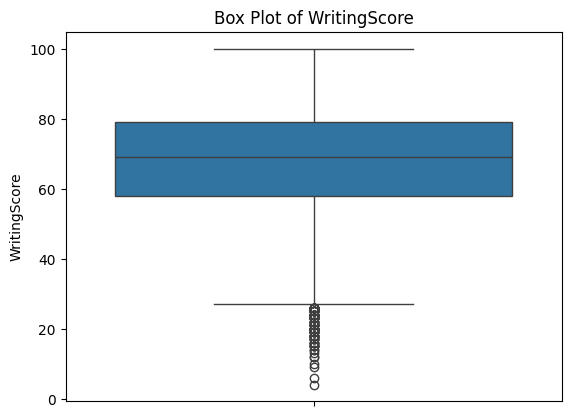

In [21]:
for col in numerical_data.columns:
  plt.figure()
  sns.boxplot(y=numerical_data[col])
  plt.title(f'Box Plot of {col}')
  plt.show()

In [22]:
outlier_indices = {}

for col in numerical_data.columns:
    Q1 = numerical_data[col].quantile(0.25)
    Q3 = numerical_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (numerical_data[col] < lower) | (numerical_data[col] > upper)
    outlier_indices[col] = numerical_data[outlier_mask].index



In [23]:
outlier_indices

{'NrSiblings': Index([   91,   183,   287,   409,   441,   546,   617,   802,   828,   868,
        ...
        27719, 27948, 28077, 28143, 28165, 28284, 28310, 28433, 28835, 28893],
       dtype='int64', length=291),
 'MathScore': Index([   17,    55,   136,   751,   928,  2984,  3209,  3283,  3738,  4052,
         4260,  4311,  4622,  4719,  4886,  4966,  5084,  5263,  5513,  5641,
         6892,  7423,  7440,  7553,  8428,  8785,  9046,  9268, 10164, 10327,
        11333, 11446, 12283, 12526, 12789, 13621, 13821, 13846, 14274, 14494,
        15133, 15653, 16480, 17540, 18385, 18690, 18862, 19688, 20127, 20249,
        20603, 20860, 20983, 21062, 21119, 21477, 21556, 21585, 22098, 22153,
        23217, 25507, 25785, 26048, 26066, 26373, 26792, 26926, 27323, 27893,
        28155, 28536, 28544, 28597, 29000, 29654],
       dtype='int64'),
 'ReadingScore': Index([   55,    69,   308,   565,   928,  1343,  1344,  1484,  3197,  4083,
         4232,  4245,  4260,  4719,  4886,  5174,  5263

In [24]:
cleaned_numerical_data = numerical_data.copy()

for col in numerical_data:
    Q1 = numerical_data[col].quantile(0.25)
    Q3 = numerical_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cleaned_numerical_data.loc[cleaned_numerical_data[col] < lower, col] = cleaned_numerical_data[col].median()
    cleaned_numerical_data.loc[cleaned_numerical_data[col] > upper, col] = cleaned_numerical_data[col].median()

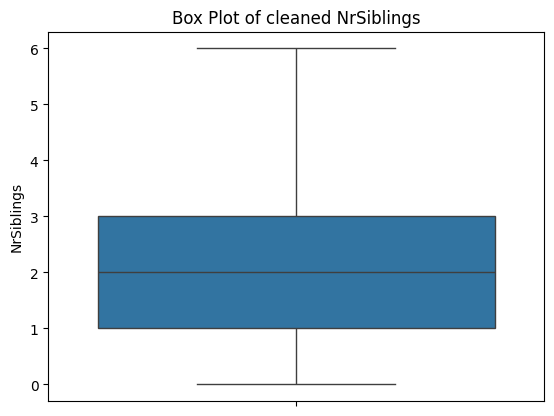

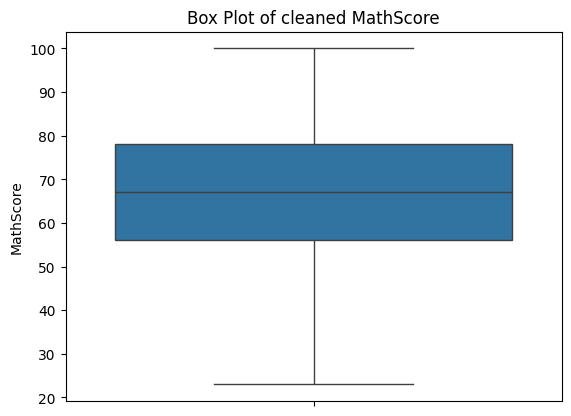

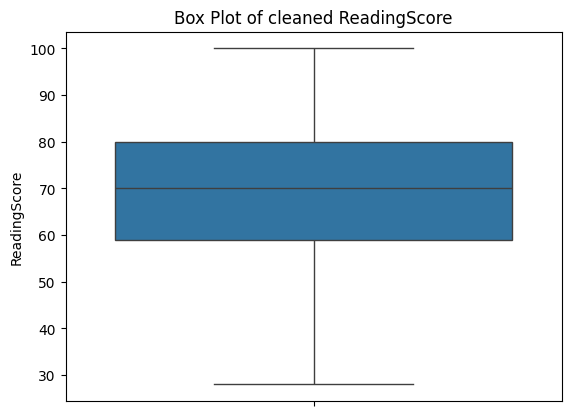

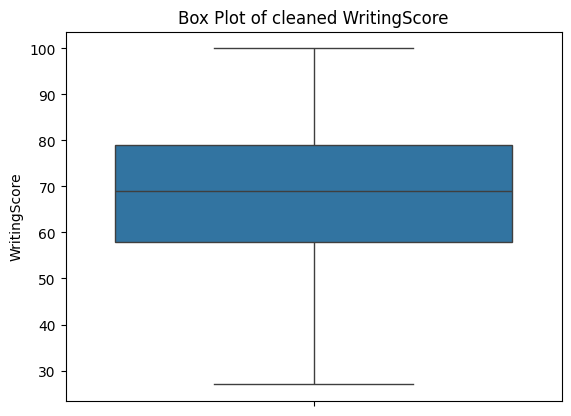

In [25]:
for col in cleaned_numerical_data:
  plt.figure()
  sns.boxplot(y=cleaned_numerical_data[col])
  plt.title(f'Box Plot of cleaned {col}')
  plt.show()

In [26]:
data[cleaned_numerical_data.columns] = cleaned_numerical_data

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               30641 non-null  object
 1   EthnicGroup          30641 non-null  object
 2   ParentEduc           30641 non-null  object
 3   LunchType            30641 non-null  object
 4   TestPrep             30641 non-null  object
 5   ParentMaritalStatus  30641 non-null  object
 6   PracticeSport        30641 non-null  object
 7   IsFirstChild         30641 non-null  object
 8   NrSiblings           30641 non-null  int64 
 9   TransportMeans       30641 non-null  object
 10  WklyStudyHours       30641 non-null  object
 11  MathScore            30641 non-null  int64 
 12  ReadingScore         30641 non-null  int64 
 13  WritingScore         30641 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 3.3+ MB


## Organizing Data
* Dividing each target column into it's own DataFrame

### MathScore_df

In [28]:
MathScore_df = data.drop(columns=['ReadingScore', 'WritingScore'])

#### Splitting the Data

In [29]:
features = MathScore_df.drop(columns=['MathScore'])
target = MathScore_df[['MathScore']]

In [30]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [31]:
print("Train Data Size")

print(f"x_train --> {len(x_train)}")
print(f"y_train --> {len(y_train)}")

print("------------------")

print("Test Data Size")

print(f"x_test --> {len(x_test)}")
print(f"y_test --> {len(y_test)}")




Train Data Size
x_train --> 24512
y_train --> 24512
------------------
Test Data Size
x_test --> 6129
y_test --> 6129


#### Categorical Labeling

* y/targets are numbers so no labeling needed
* ['ParentEduc', 'PracticeSport', 'WklyStudyHours'] are ordinal categories
* ['Gender', 'EthnicGroup', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'IsFirstChild', 'TransportMeans'] are nominal categories


In [32]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24512 entries, 9061 to 23654
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               24512 non-null  object
 1   EthnicGroup          24512 non-null  object
 2   ParentEduc           24512 non-null  object
 3   LunchType            24512 non-null  object
 4   TestPrep             24512 non-null  object
 5   ParentMaritalStatus  24512 non-null  object
 6   PracticeSport        24512 non-null  object
 7   IsFirstChild         24512 non-null  object
 8   NrSiblings           24512 non-null  int64 
 9   TransportMeans       24512 non-null  object
 10  WklyStudyHours       24512 non-null  object
dtypes: int64(1), object(10)
memory usage: 2.2+ MB


In [33]:
x_train_cat = x_train.select_dtypes(['object'])
x_test_cat = x_test.select_dtypes(['object'])

x_train_num = x_train.select_dtypes(['int64'])
x_test_num = x_test.select_dtypes(['int64'])

In [34]:
for col in x_train_cat.columns:
  print(f"{x_train_cat[col].value_counts()}")
  print("-----------"*5)

Gender
female    12334
male      12178
Name: count, dtype: int64
-------------------------------------------------------
EthnicGroup
group C    8848
group D    5959
group B    4673
group E    3241
group A    1791
Name: count, dtype: int64
-------------------------------------------------------
ParentEduc
some college          6810
high school           4497
associate's degree    4421
some high school      4420
bachelor's degree     2739
master's degree       1625
Name: count, dtype: int64
-------------------------------------------------------
LunchType
standard        15925
free/reduced     8587
Name: count, dtype: int64
-------------------------------------------------------
TestPrep
none         16538
completed     7974
Name: count, dtype: int64
-------------------------------------------------------
ParentMaritalStatus
married     14395
single       5694
divorced     3950
widowed       473
Name: count, dtype: int64
-------------------------------------------------------
PracticeSpo

In [35]:
# Ordinal Features Order
ParentEduc_order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
PracticeSport_order = ['never', 'sometimes', 'regularly']
WklyStudyHours_order = ['< 5', '5 - 10', '> 10']

In [36]:
ordinal_features = ['ParentEduc', 'PracticeSport', 'WklyStudyHours']
nominal_features = ['Gender', 'EthnicGroup', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'IsFirstChild', 'TransportMeans']

In [37]:
oe = OrdinalEncoder(categories=[ParentEduc_order, PracticeSport_order, WklyStudyHours_order])

In [38]:
x_train_cat[ordinal_features] = oe.fit_transform(x_train_cat[ordinal_features])
x_test_cat[ordinal_features] = oe.transform(x_test_cat[ordinal_features])

In [39]:
print(x_train_cat.head())
print('-------'*5)
print(x_test_cat.head())

       Gender EthnicGroup  ParentEduc     LunchType TestPrep  \
9061     male     group A         2.0      standard     none   
26137    male     group E         2.0  free/reduced     none   
16599    male     group D         4.0      standard     none   
21992  female     group C         4.0  free/reduced     none   
18672    male     group C         5.0  free/reduced     none   

      ParentMaritalStatus  PracticeSport IsFirstChild TransportMeans  \
9061              married            2.0          yes     school_bus   
26137              single            1.0           no        private   
16599             married            1.0          yes     school_bus   
21992             married            1.0           no        private   
18672              single            1.0          yes        private   

       WklyStudyHours  
9061              1.0  
26137             1.0  
16599             0.0  
21992             1.0  
18672             1.0  
-----------------------------------
  

In [40]:
ohe = OneHotEncoder(drop= 'if_binary', sparse_output=False)

In [41]:
x_train_cat_enc = pd.DataFrame(ohe.fit_transform(x_train_cat[nominal_features]),
                               index=x_train_cat.index,
                               columns = ohe.get_feature_names_out(nominal_features))
x_test_cat_enc = pd.DataFrame(ohe.transform(x_test_cat[nominal_features]),
                              index=x_test_cat.index,
                              columns= ohe.get_feature_names_out(nominal_features))

In [42]:
x_train_cat = pd.concat([x_train_cat.drop(columns=nominal_features), x_train_cat_enc], axis=1)
x_test_cat = pd.concat([x_test_cat.drop(columns=nominal_features), x_test_cat_enc], axis=1)

In [43]:
x_train_cat.head()

,ParentEduc,PracticeSport,WklyStudyHours,Gender_male,EthnicGroup_group A,EthnicGroup_group B,EthnicGroup_group C,EthnicGroup_group D,EthnicGroup_group E,LunchType_standard,TestPrep_none,ParentMaritalStatus_divorced,ParentMaritalStatus_married,ParentMaritalStatus_single,ParentMaritalStatus_widowed,IsFirstChild_yes,TransportMeans_school_bus
9061,2.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
26137,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
16599,4.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
21992,4.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
18672,5.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [44]:
x_train_cat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24512 entries, 9061 to 23654
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParentEduc                    24512 non-null  float64
 1   PracticeSport                 24512 non-null  float64
 2   WklyStudyHours                24512 non-null  float64
 3   Gender_male                   24512 non-null  float64
 4   EthnicGroup_group A           24512 non-null  float64
 5   EthnicGroup_group B           24512 non-null  float64
 6   EthnicGroup_group C           24512 non-null  float64
 7   EthnicGroup_group D           24512 non-null  float64
 8   EthnicGroup_group E           24512 non-null  float64
 9   LunchType_standard            24512 non-null  float64
 10  TestPrep_none                 24512 non-null  float64
 11  ParentMaritalStatus_divorced  24512 non-null  float64
 12  ParentMaritalStatus_married   24512 non-null  float64
 13  Par

In [45]:
x_test_cat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6129 entries, 21861 to 23872
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParentEduc                    6129 non-null   float64
 1   PracticeSport                 6129 non-null   float64
 2   WklyStudyHours                6129 non-null   float64
 3   Gender_male                   6129 non-null   float64
 4   EthnicGroup_group A           6129 non-null   float64
 5   EthnicGroup_group B           6129 non-null   float64
 6   EthnicGroup_group C           6129 non-null   float64
 7   EthnicGroup_group D           6129 non-null   float64
 8   EthnicGroup_group E           6129 non-null   float64
 9   LunchType_standard            6129 non-null   float64
 10  TestPrep_none                 6129 non-null   float64
 11  ParentMaritalStatus_divorced  6129 non-null   float64
 12  ParentMaritalStatus_married   6129 non-null   float64
 13  Par

In [46]:
x_train = pd.concat([x_train_cat, x_train_num], axis=1)
x_test = pd.concat([x_test_cat, x_test_num], axis=1)


In [47]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24512 entries, 9061 to 23654
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParentEduc                    24512 non-null  float64
 1   PracticeSport                 24512 non-null  float64
 2   WklyStudyHours                24512 non-null  float64
 3   Gender_male                   24512 non-null  float64
 4   EthnicGroup_group A           24512 non-null  float64
 5   EthnicGroup_group B           24512 non-null  float64
 6   EthnicGroup_group C           24512 non-null  float64
 7   EthnicGroup_group D           24512 non-null  float64
 8   EthnicGroup_group E           24512 non-null  float64
 9   LunchType_standard            24512 non-null  float64
 10  TestPrep_none                 24512 non-null  float64
 11  ParentMaritalStatus_divorced  24512 non-null  float64
 12  ParentMaritalStatus_married   24512 non-null  float64
 13  Par

In [48]:
x_train = x_train.astype('int64')
x_test = x_test.astype('int64')
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24512 entries, 9061 to 23654
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   ParentEduc                    24512 non-null  int64
 1   PracticeSport                 24512 non-null  int64
 2   WklyStudyHours                24512 non-null  int64
 3   Gender_male                   24512 non-null  int64
 4   EthnicGroup_group A           24512 non-null  int64
 5   EthnicGroup_group B           24512 non-null  int64
 6   EthnicGroup_group C           24512 non-null  int64
 7   EthnicGroup_group D           24512 non-null  int64
 8   EthnicGroup_group E           24512 non-null  int64
 9   LunchType_standard            24512 non-null  int64
 10  TestPrep_none                 24512 non-null  int64
 11  ParentMaritalStatus_divorced  24512 non-null  int64
 12  ParentMaritalStatus_married   24512 non-null  int64
 13  ParentMaritalStatus_single    245

#### Scaling

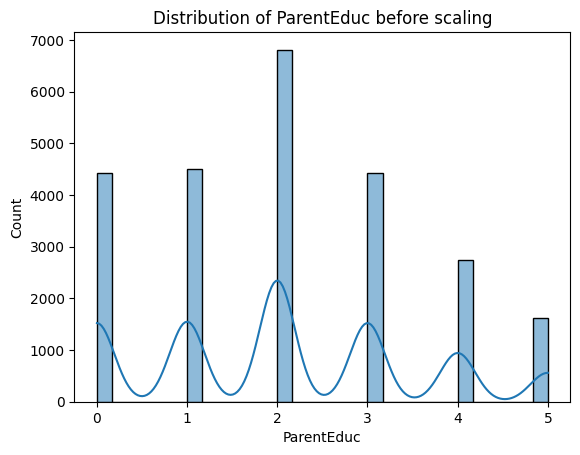

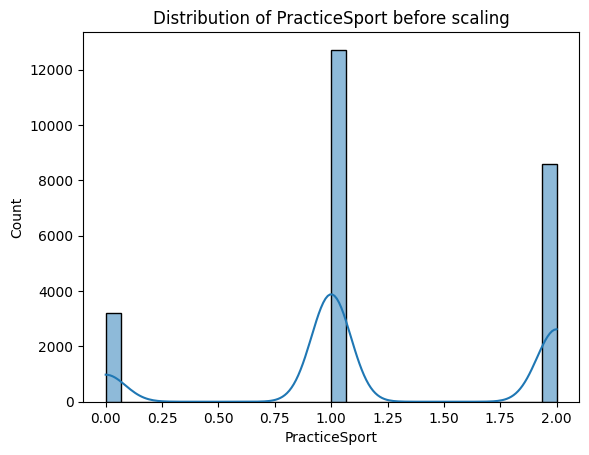

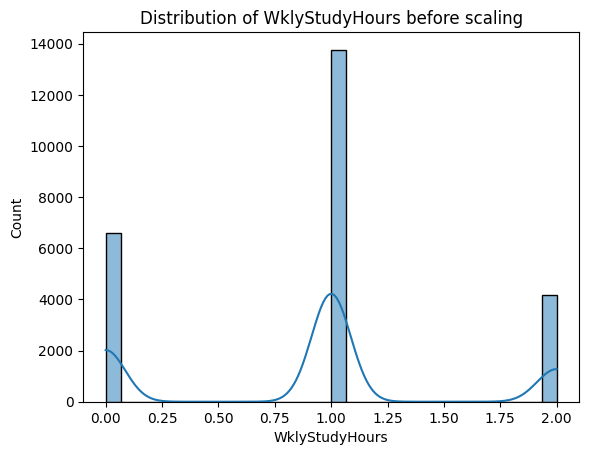

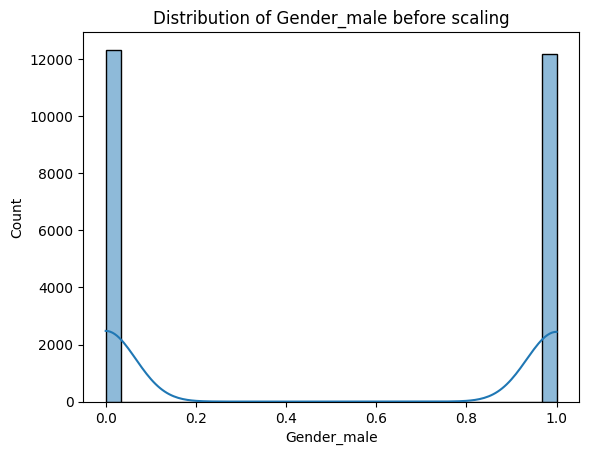

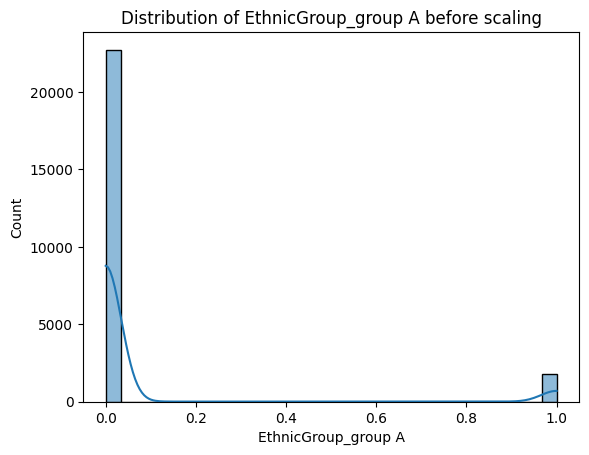

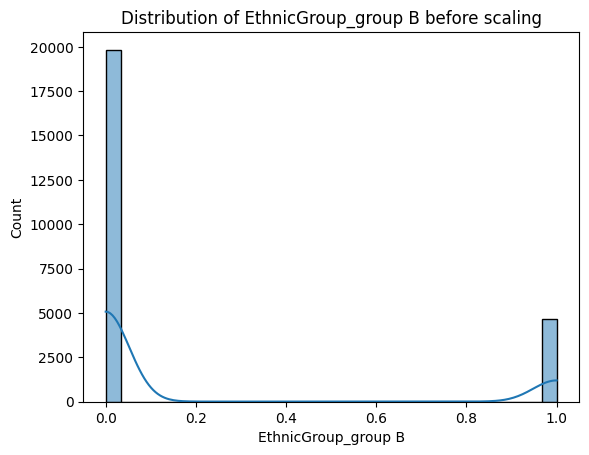

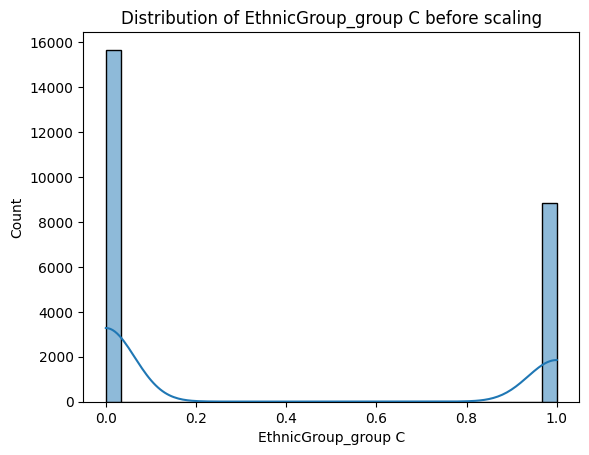

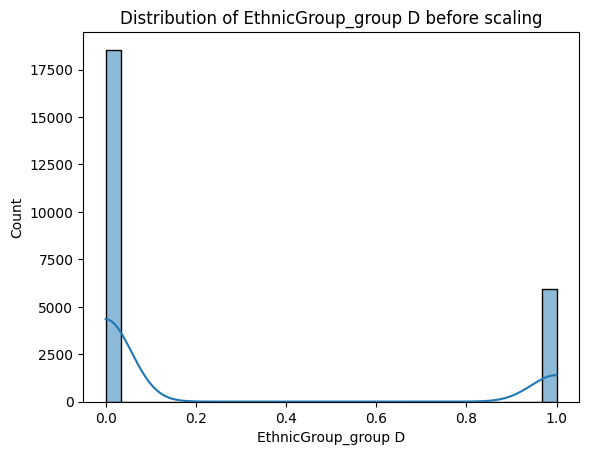

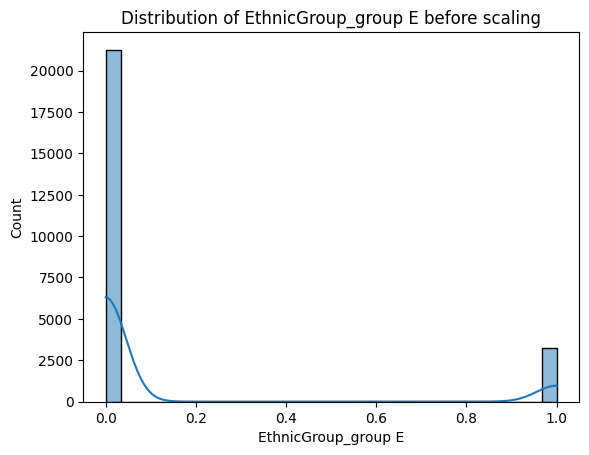

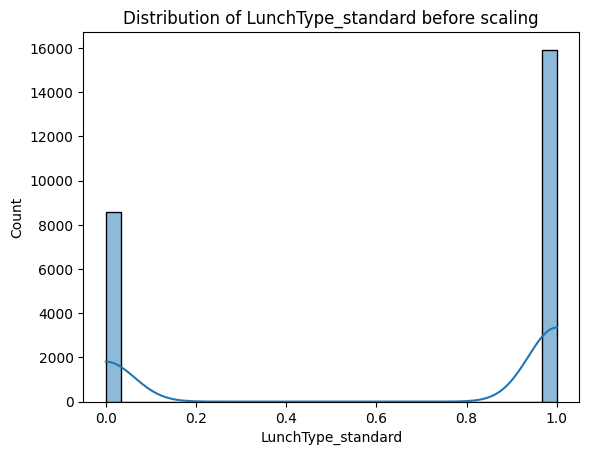

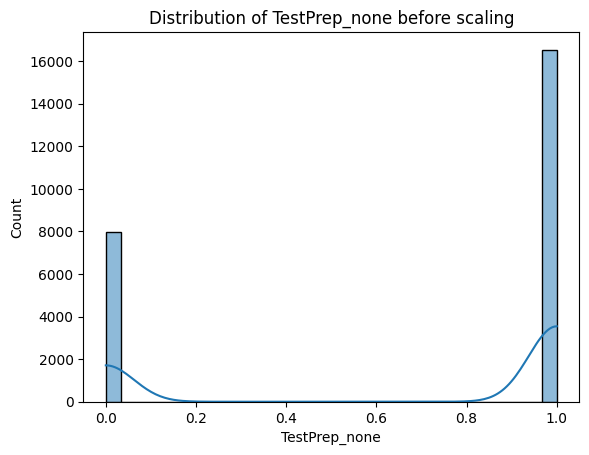

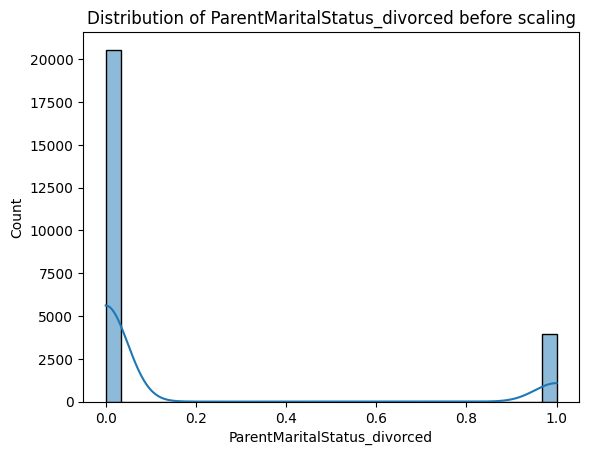

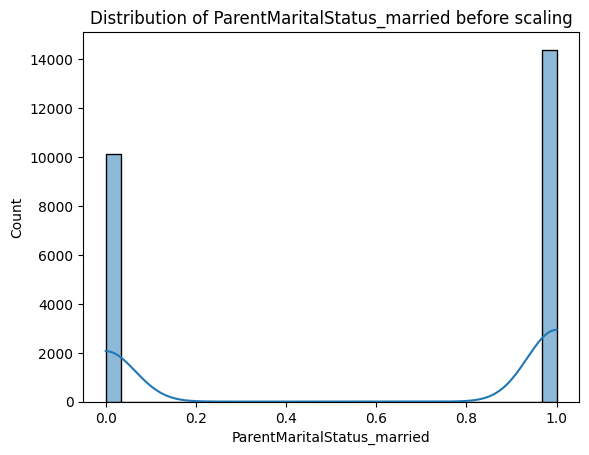

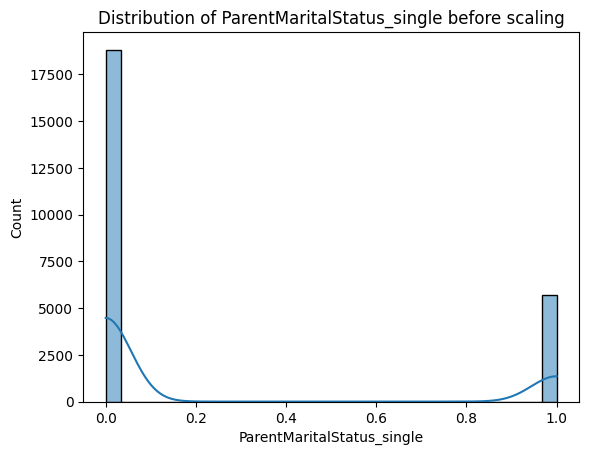

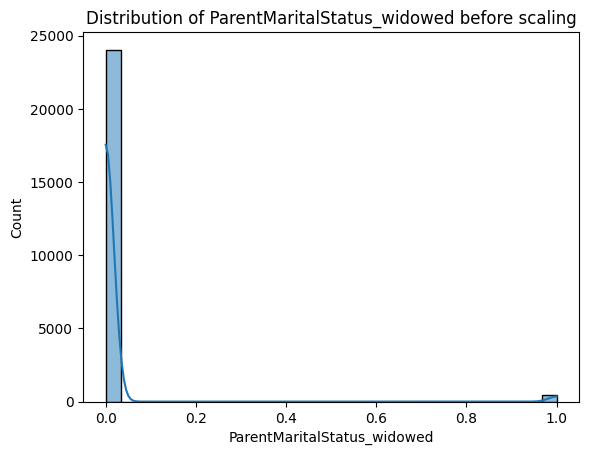

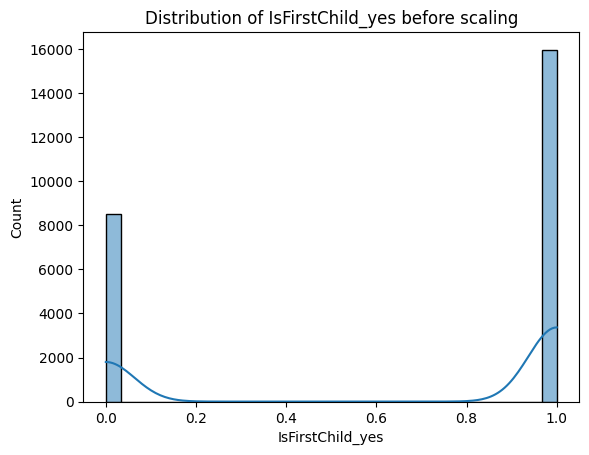

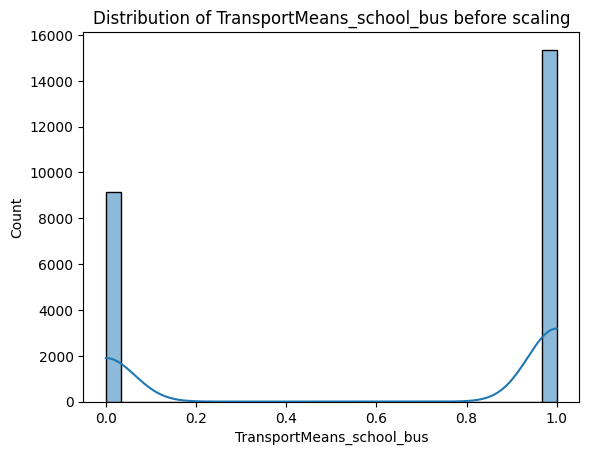

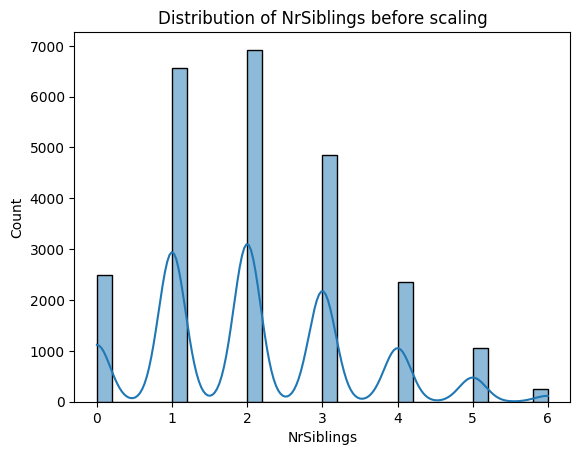

In [49]:
for col in x_train.columns:
  sns.histplot(x_train[col], kde=True, bins=30)
  plt.title(f'Distribution of {col} before scaling')
  plt.show()

In [50]:
MMScaler = MinMaxScaler()

In [51]:
x_train = pd.DataFrame(MMScaler.fit_transform(x_train),
                       columns=x_train.columns)
x_test = pd.DataFrame(MMScaler.transform(x_test),
                      columns=x_test.columns)

y_train = pd.DataFrame(MMScaler.fit_transform(y_train),
                       columns=y_train.columns)
y_test = pd.DataFrame(MMScaler.transform(y_test),
                      columns=y_test.columns)

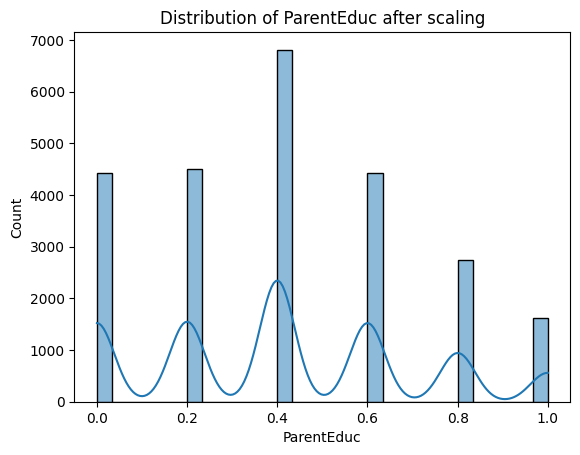

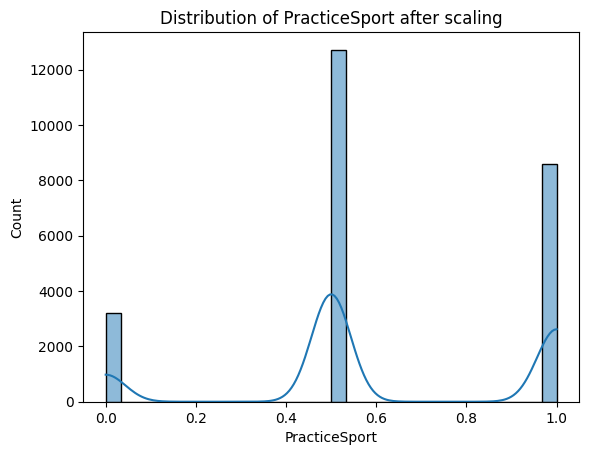

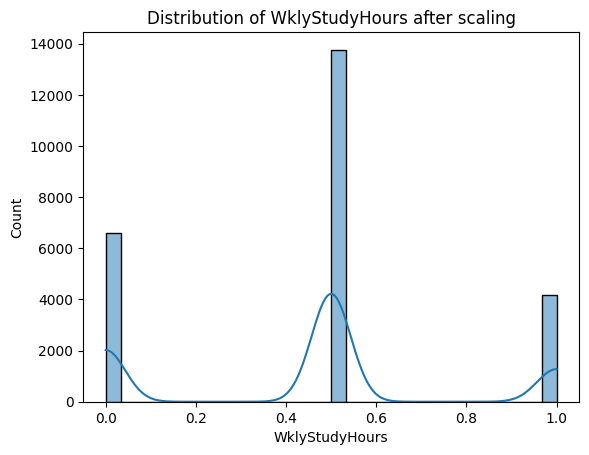

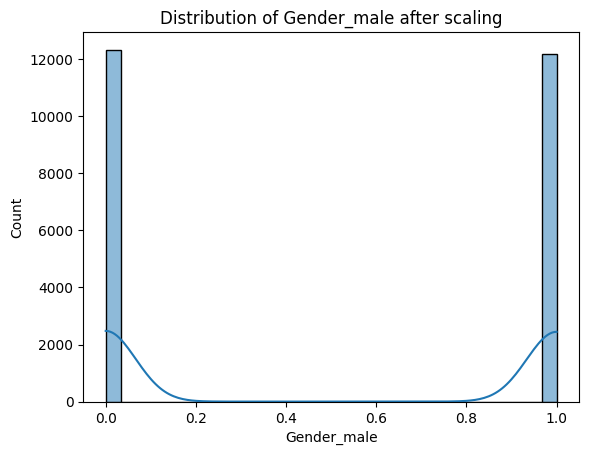

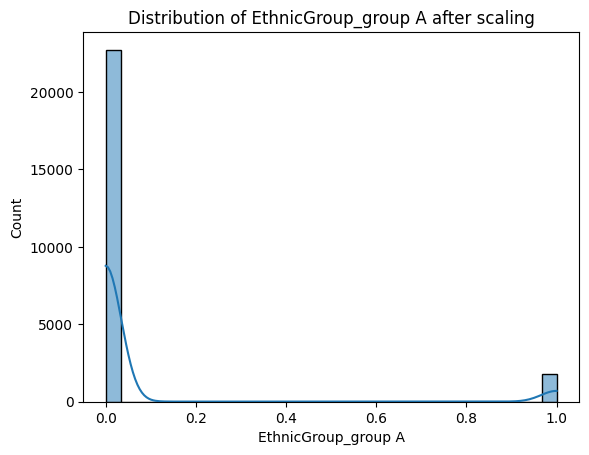

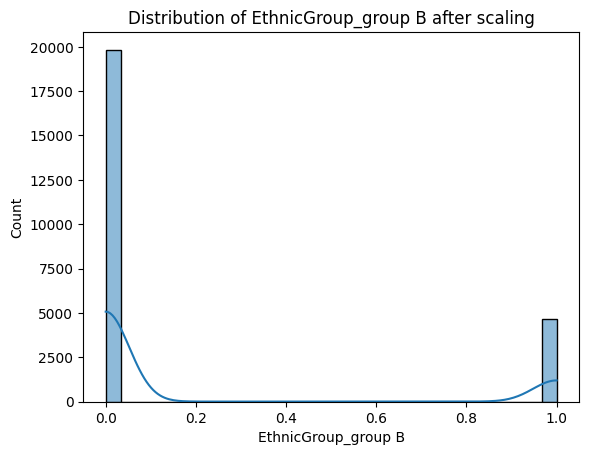

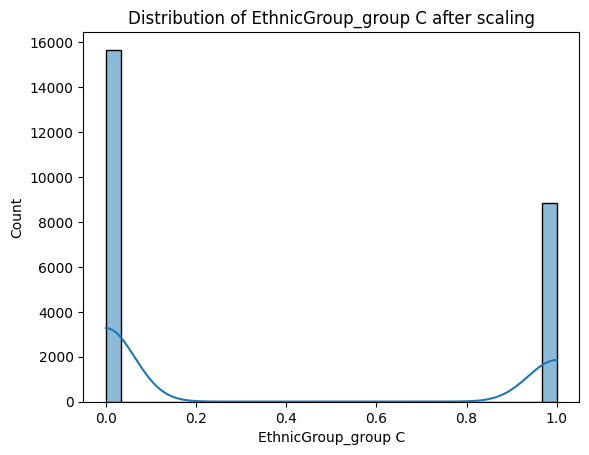

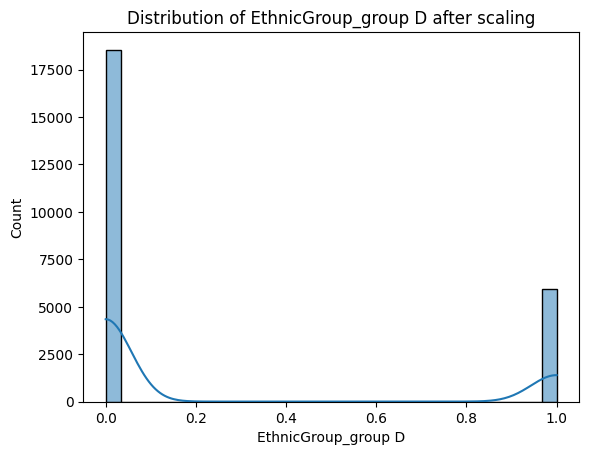

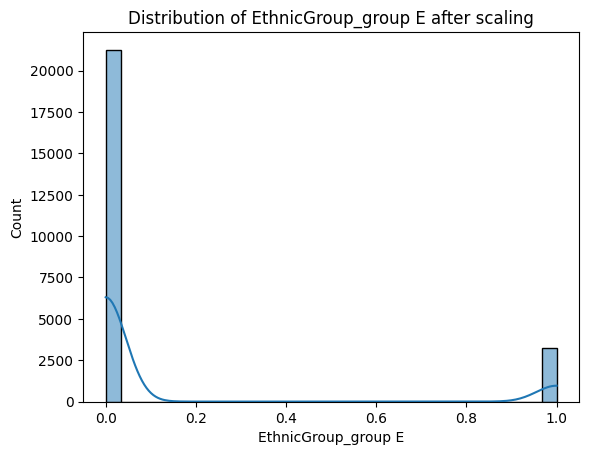

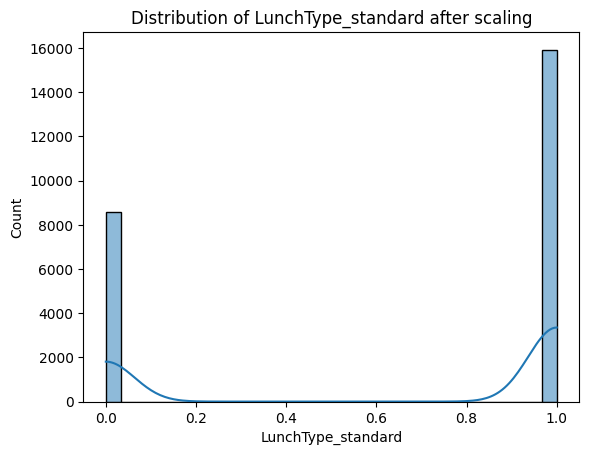

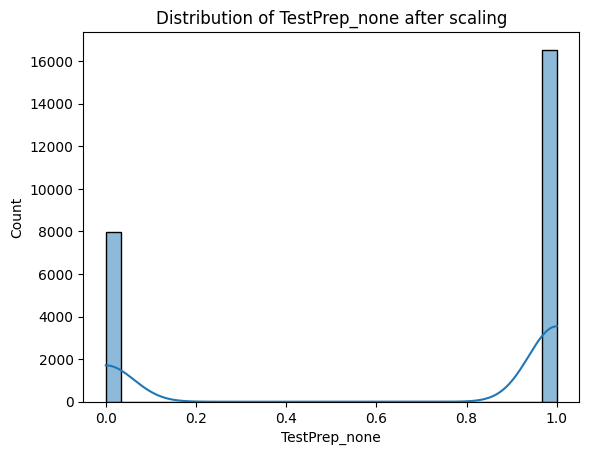

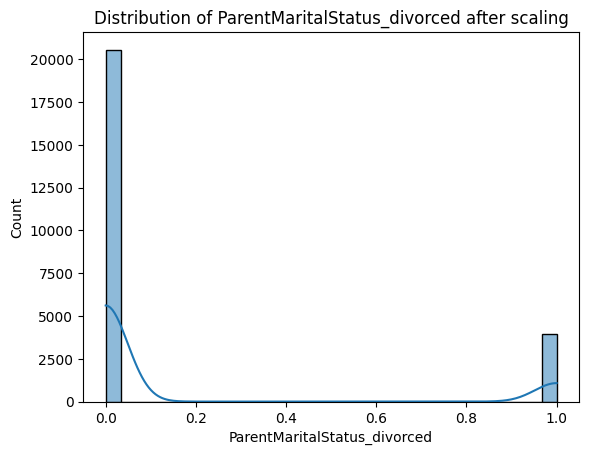

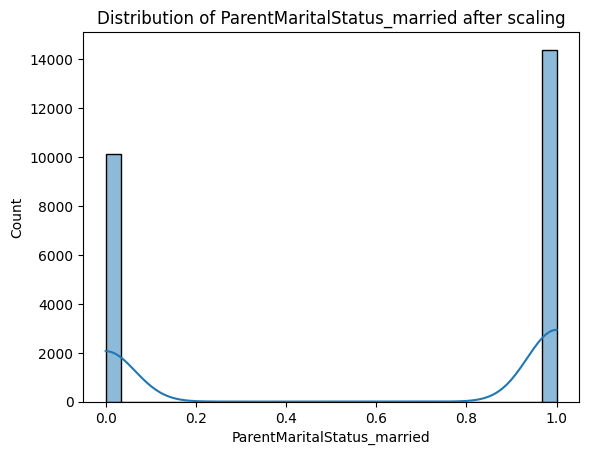

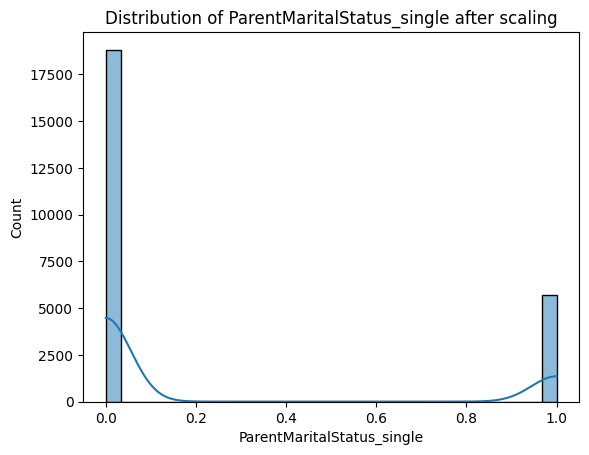

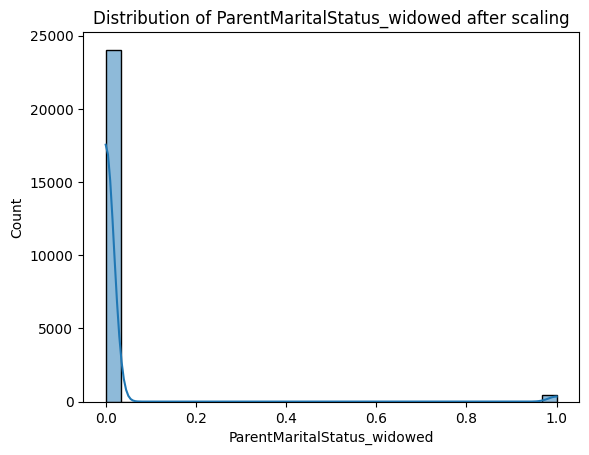

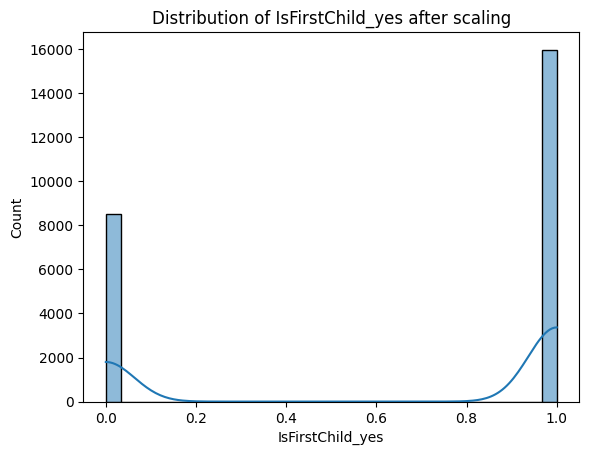

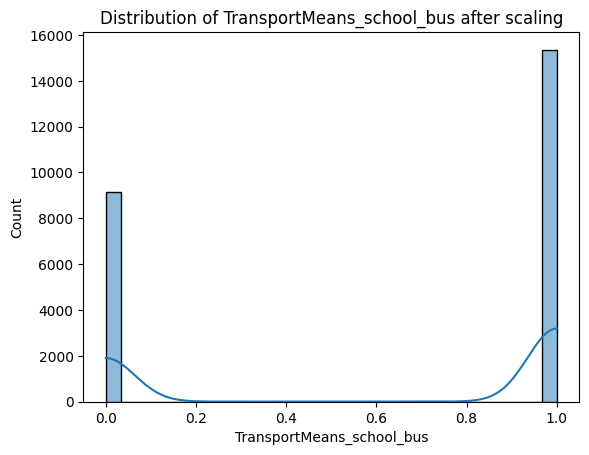

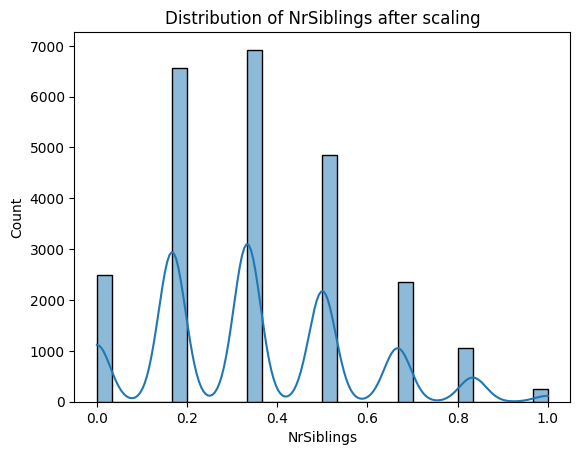

In [52]:
for col in x_train.columns:
  sns.histplot(x_train[col], kde=True, bins=30)
  plt.title(f'Distribution of {col} after scaling')
  plt.show()

#### Building Model

In [53]:
lr = LinearRegression()

In [54]:
lr.fit(x_train, y_train)

LinearRegression()

In [55]:
y_pred = lr.predict(x_test)
y_pred

array([[0.5263469 ],
       [0.80204731],
       [0.6095996 ],
       ...,
       [0.43880686],
       [0.67011729],
       [0.56559371]])

In [56]:
print(f'Ypred ---> {y_pred.shape}')
print(f'test ---> {y_test.shape}')

Ypred ---> (6129, 1)
test ---> (6129, 1)


#### Preformance Measure

In [57]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.027214792601251113
RMSE: 0.16496906558882823
MAE : 0.13392787295998923
R²  : 0.282460314472997


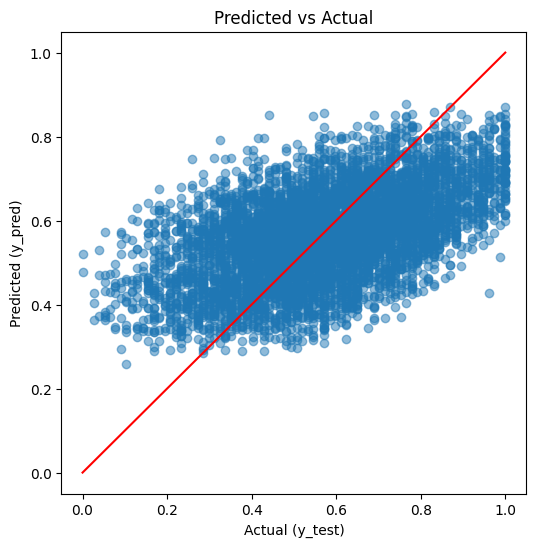

In [58]:
y_test_flat = y_test.to_numpy().ravel()
y_pred_flat = y_pred.ravel()

plt.figure(figsize=(6,6))
plt.scatter(y_test_flat, y_pred_flat, alpha=0.5)

lims = [min(y_test_flat.min(), y_pred_flat.min()),
        max(y_test_flat.max(), y_pred_flat.max())]

plt.plot(lims, lims, color="red")

plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Predicted vs Actual")
plt.show()


### ReadingScore_df

In [59]:
ReadingScore_df = data.drop(['MathScore', 'WritingScore'], axis=1)

MSE : 0.031133119230695058
RMSE: 0.17644579686321535
MAE : 0.14346548496539957
R²  : 0.22786276216919965


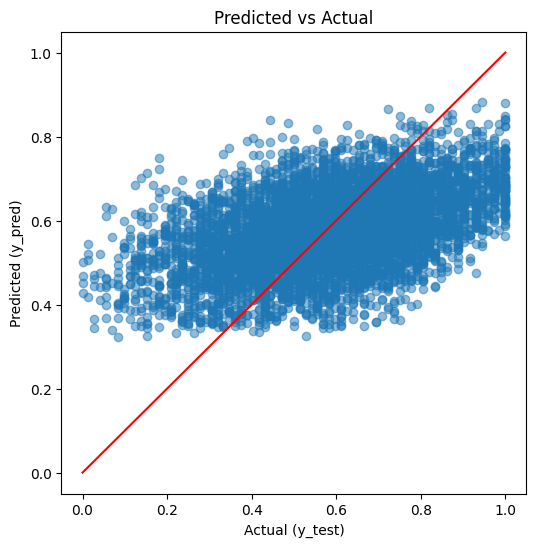

In [60]:
features = ReadingScore_df.drop(columns=['ReadingScore'])
target = ReadingScore_df[['ReadingScore']]

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


x_train_cat = x_train.select_dtypes(['object'])
x_test_cat = x_test.select_dtypes(['object'])

x_train_num = x_train.select_dtypes(['int64'])
x_test_num = x_test.select_dtypes(['int64'])


# Ordinal Features Order
ParentEduc_order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
PracticeSport_order = ['never', 'sometimes', 'regularly']
WklyStudyHours_order = ['< 5', '5 - 10', '> 10']

ordinal_features = ['ParentEduc', 'PracticeSport', 'WklyStudyHours']
nominal_features = ['Gender', 'EthnicGroup', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'IsFirstChild', 'TransportMeans']

oe = OrdinalEncoder(categories=[ParentEduc_order, PracticeSport_order, WklyStudyHours_order])


x_train_cat[ordinal_features] = oe.fit_transform(x_train_cat[ordinal_features])
x_test_cat[ordinal_features] = oe.transform(x_test_cat[ordinal_features])

ohe = OneHotEncoder(drop= 'if_binary', sparse_output=False)


x_train_cat_enc = pd.DataFrame(ohe.fit_transform(x_train_cat[nominal_features]),
                               index=x_train_cat.index,
                               columns = ohe.get_feature_names_out(nominal_features))
x_test_cat_enc = pd.DataFrame(ohe.transform(x_test_cat[nominal_features]),
                              index=x_test_cat.index,
                              columns= ohe.get_feature_names_out(nominal_features))

x_train_cat = pd.concat([x_train_cat.drop(columns=nominal_features), x_train_cat_enc], axis=1)
x_test_cat = pd.concat([x_test_cat.drop(columns=nominal_features), x_test_cat_enc], axis=1)

x_train = pd.concat([x_train_cat, x_train_num], axis=1)
x_test = pd.concat([x_test_cat, x_test_num], axis=1)


x_train = x_train.astype('int64')
x_test = x_test.astype('int64')


MMScaler = MinMaxScaler()


x_train = pd.DataFrame(MMScaler.fit_transform(x_train),
                       columns=x_train.columns)
x_test = pd.DataFrame(MMScaler.transform(x_test),
                      columns=x_test.columns)

y_train = pd.DataFrame(MMScaler.fit_transform(y_train),
                       columns=y_train.columns)
y_test = pd.DataFrame(MMScaler.transform(y_test),
                      columns=y_test.columns)


lr = LinearRegression()

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


y_test_flat = y_test.to_numpy().ravel()
y_pred_flat = y_pred.ravel()

plt.figure(figsize=(6,6))
plt.scatter(y_test_flat, y_pred_flat, alpha=0.5)

lims = [min(y_test_flat.min(), y_pred_flat.min()),
        max(y_test_flat.max(), y_pred_flat.max())]

plt.plot(lims, lims, color="red")

plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Predicted vs Actual")
plt.show()


### WritingScore_df

In [61]:
WritingScore_df = data.drop(['MathScore', 'ReadingScore'], axis=1)

MSE : 0.029014006412604435
RMSE: 0.17033498293833957
MAE : 0.13842967913305984
R²  : 0.32516726438624477


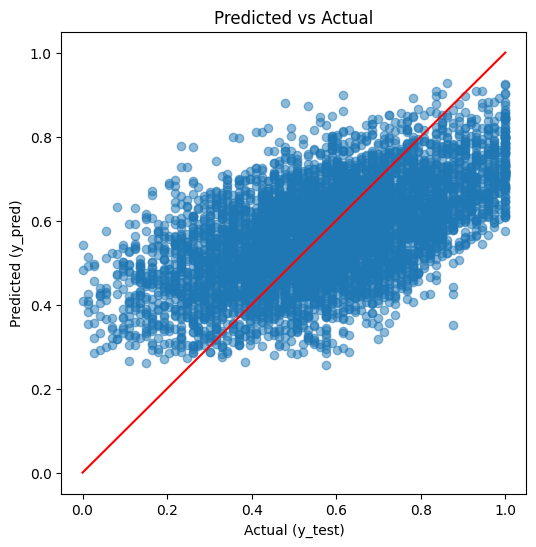

In [62]:
features = WritingScore_df.drop(columns=['WritingScore'])
target = WritingScore_df[['WritingScore']]

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


x_train_cat = x_train.select_dtypes(['object'])
x_test_cat = x_test.select_dtypes(['object'])

x_train_num = x_train.select_dtypes(['int64'])
x_test_num = x_test.select_dtypes(['int64'])


# Ordinal Features Order
ParentEduc_order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
PracticeSport_order = ['never', 'sometimes', 'regularly']
WklyStudyHours_order = ['< 5', '5 - 10', '> 10']

ordinal_features = ['ParentEduc', 'PracticeSport', 'WklyStudyHours']
nominal_features = ['Gender', 'EthnicGroup', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'IsFirstChild', 'TransportMeans']

oe = OrdinalEncoder(categories=[ParentEduc_order, PracticeSport_order, WklyStudyHours_order])


x_train_cat[ordinal_features] = oe.fit_transform(x_train_cat[ordinal_features])
x_test_cat[ordinal_features] = oe.transform(x_test_cat[ordinal_features])

ohe = OneHotEncoder(drop= 'if_binary', sparse_output=False)


x_train_cat_enc = pd.DataFrame(ohe.fit_transform(x_train_cat[nominal_features]),
                               index=x_train_cat.index,
                               columns = ohe.get_feature_names_out(nominal_features))
x_test_cat_enc = pd.DataFrame(ohe.transform(x_test_cat[nominal_features]),
                              index=x_test_cat.index,
                              columns= ohe.get_feature_names_out(nominal_features))

x_train_cat = pd.concat([x_train_cat.drop(columns=nominal_features), x_train_cat_enc], axis=1)
x_test_cat = pd.concat([x_test_cat.drop(columns=nominal_features), x_test_cat_enc], axis=1)

x_train = pd.concat([x_train_cat, x_train_num], axis=1)
x_test = pd.concat([x_test_cat, x_test_num], axis=1)


x_train = x_train.astype('int64')
x_test = x_test.astype('int64')


MMScaler = MinMaxScaler()


x_train = pd.DataFrame(MMScaler.fit_transform(x_train),
                       columns=x_train.columns)
x_test = pd.DataFrame(MMScaler.transform(x_test),
                      columns=x_test.columns)

y_train = pd.DataFrame(MMScaler.fit_transform(y_train),
                       columns=y_train.columns)
y_test = pd.DataFrame(MMScaler.transform(y_test),
                      columns=y_test.columns)


lr = LinearRegression()

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)


y_test_flat = y_test.to_numpy().ravel()
y_pred_flat = y_pred.ravel()

plt.figure(figsize=(6,6))
plt.scatter(y_test_flat, y_pred_flat, alpha=0.5)

lims = [min(y_test_flat.min(), y_pred_flat.min()),
        max(y_test_flat.max(), y_pred_flat.max())]

plt.plot(lims, lims, color="red")

plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Predicted vs Actual")
plt.show()


# house_data dataset

- id: Unique identifier for each property.
- date: Date when the property was sold.
- price: Sale price of the property.
- bedrooms: Number of bedrooms in the house.
- bathrooms: Number of bathrooms in the house.
- sqft_living: Square footage of the living area.
- sqft_lot: Square footage of the lot.
- floors: Number of floors in the house.
- waterfront: Indicates if the property has a waterfront view (binary: 0 = no, 1 = yes).
- view: Quality of the view from the property (numerical scale).
- condition: Condition of the house (numerical scale).
- grade: Overall grade based on building and design (numerical scale).
- sqft_above: Square footage of the house (excluding the basement).
- sqft_basement: Square footage of the basement.
- yr_built: Year the house was built.
- yr_renovated: Year the house was renovated (0 indicates no renovations).
- zipcode: ZIP code of the property.
- lat: Latitude coordinate of the property.
- long: Longitude coordinate of the property.
- sqft_living15: Average square footage of living area for the 15 nearest neighbors.
- sqft_lot15: Average square footage of lot size for the 15 nearest neighbors

In [63]:
data = pd.read_csv('/content/house_data.csv')
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [65]:
data.drop(columns=['id'], inplace=True)

In [66]:
data.date.value_counts()  # will not be able to encode all of that so it's better to drop it as an ineffictive feature but to gain confidence I am going to plot a relation between the date and the price of the property

,count
date,
20140623T000000,142
20140626T000000,131
20140625T000000,131
20140708T000000,127
20150427T000000,126
...,...
20150131T000000,1
20150117T000000,1
20150308T000000,1


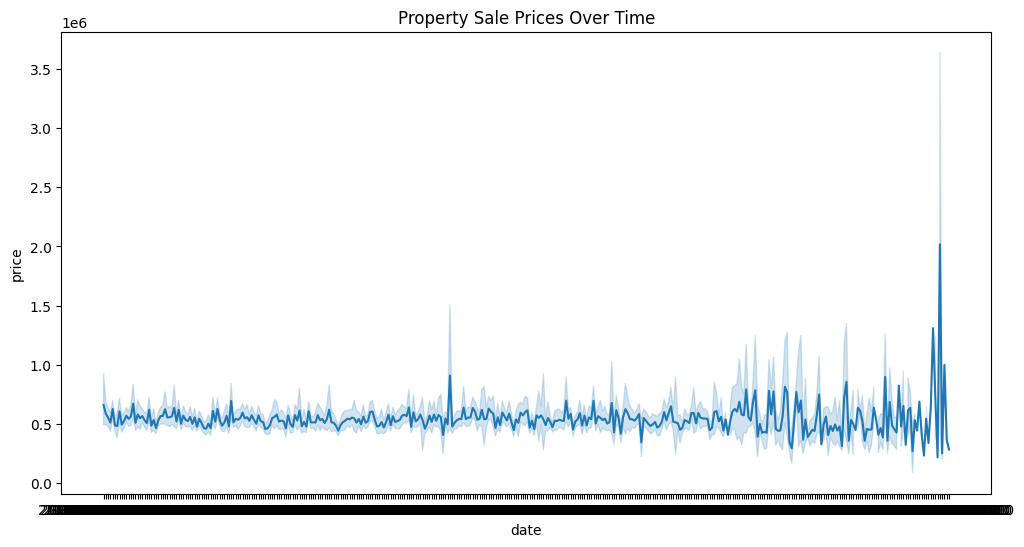

In [67]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='date', y='price')
plt.title("Property Sale Prices Over Time")
plt.show()

# No relation so better to drop it

In [68]:
data.drop(columns=['date'], inplace=True)


In [69]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [70]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [72]:
data.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


In [73]:
data.duplicated().sum()

np.int64(5)

In [74]:
data.drop_duplicates(inplace=True)

In [75]:
data.info() # Non Categorical Data

<class 'pandas.core.frame.DataFrame'>
Index: 21608 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21608 non-null  float64
 1   bedrooms       21608 non-null  int64  
 2   bathrooms      21608 non-null  float64
 3   sqft_living    21608 non-null  int64  
 4   sqft_lot       21608 non-null  int64  
 5   floors         21608 non-null  float64
 6   waterfront     21608 non-null  int64  
 7   view           21608 non-null  int64  
 8   condition      21608 non-null  int64  
 9   grade          21608 non-null  int64  
 10  sqft_above     21608 non-null  int64  
 11  sqft_basement  21608 non-null  int64  
 12  yr_built       21608 non-null  int64  
 13  yr_renovated   21608 non-null  int64  
 14  zipcode        21608 non-null  int64  
 15  lat            21608 non-null  float64
 16  long           21608 non-null  float64
 17  sqft_living15  21608 non-null  int64  
 18  sqft_lot15 

In [76]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.160800e+04,21608.000000,21608.000000,21608.000000,2.160800e+04,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000
mean,5.400984e+05,3.370927,2.114738,2079.958950,1.510962e+04,1.494146,0.007544,0.234219,3.409478,7.656655,1788.414846,291.544104,1970.999907,84.330155,98077.942614,47.560050,-122.213894,1986.583164,12770.108340
std,3.671646e+05,0.930103,0.770238,918.505805,4.142491e+04,0.539910,0.086527,0.766169,0.650782,1.175484,828.141155,442.612560,29.371463,401.517026,53.506883,0.138578,0.140830,685.421474,27307.006892
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.218375e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.470875,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230500,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.069050e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.250000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


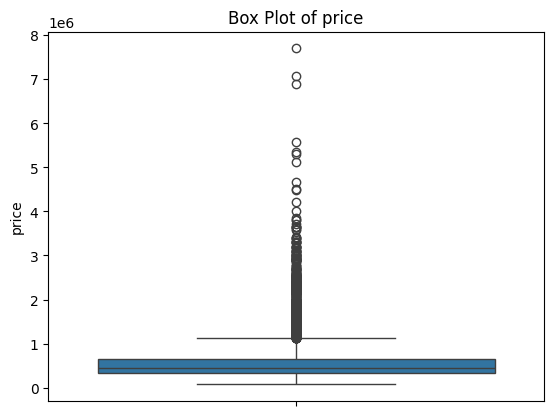

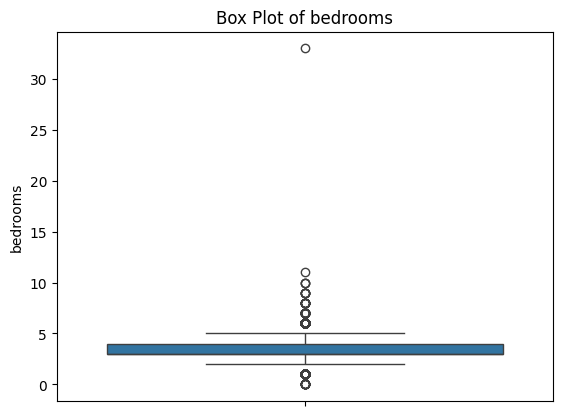

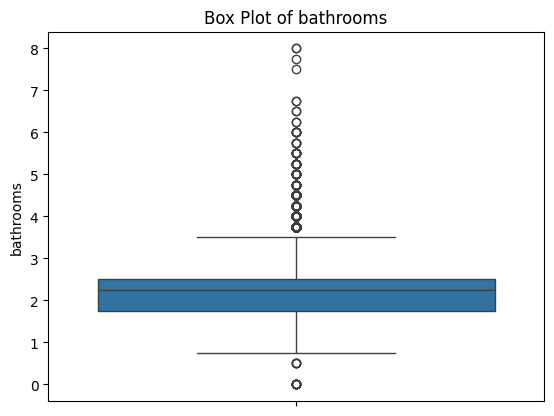

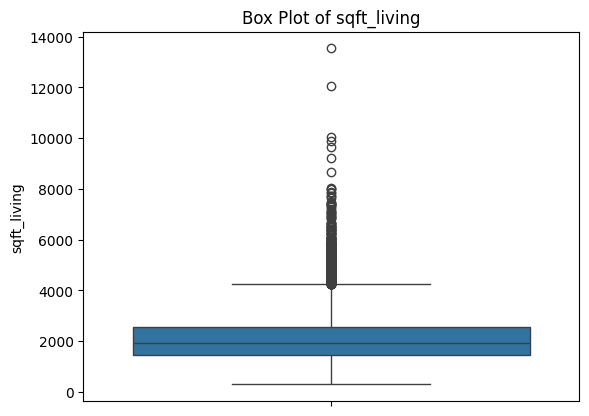

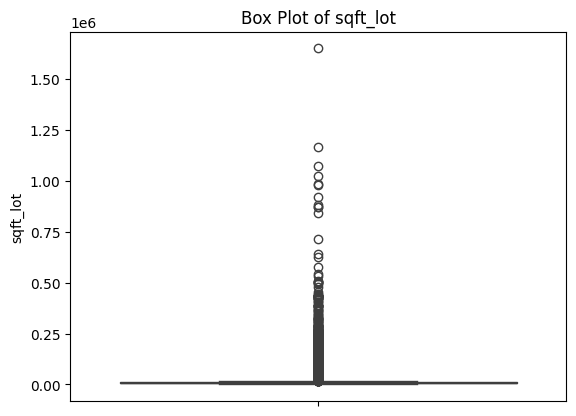

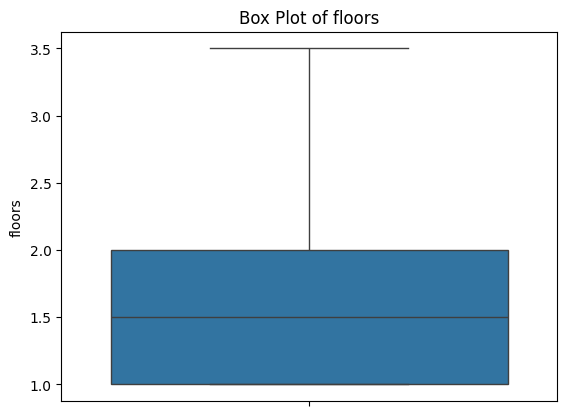

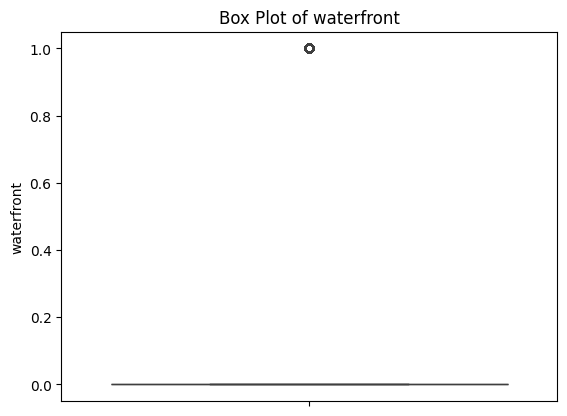

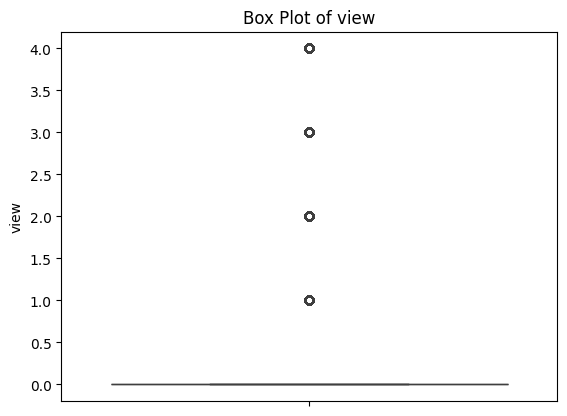

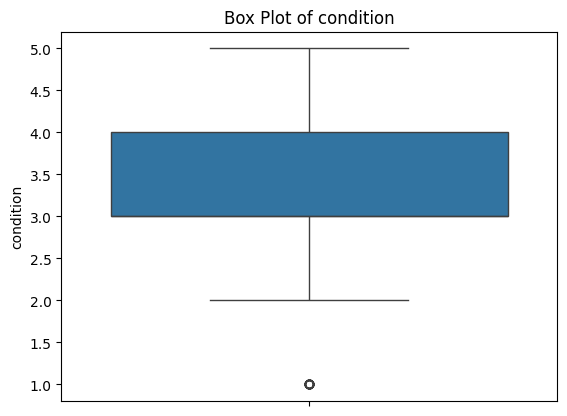

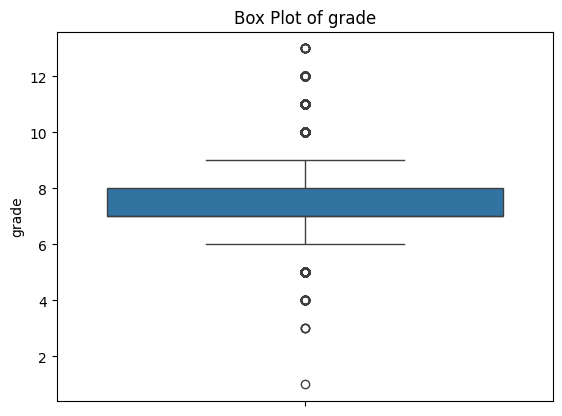

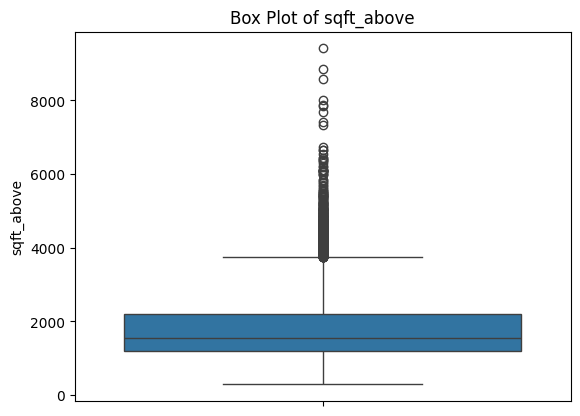

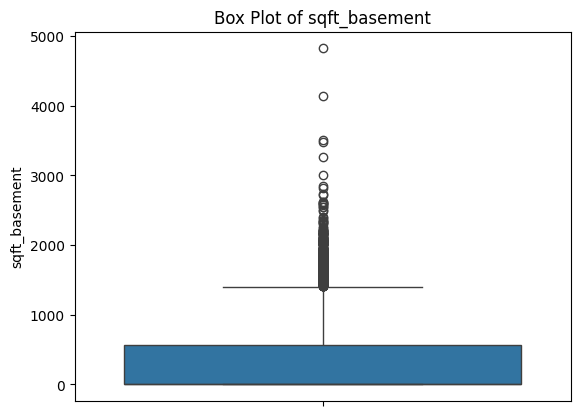

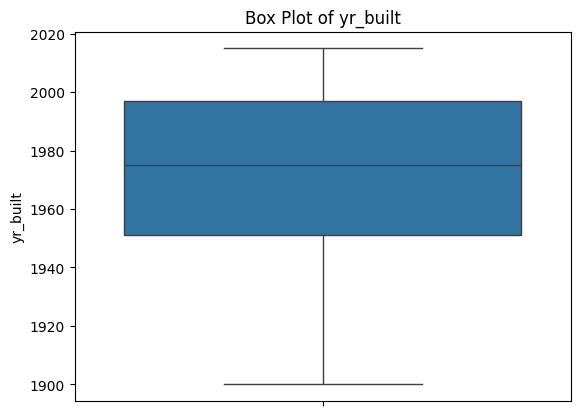

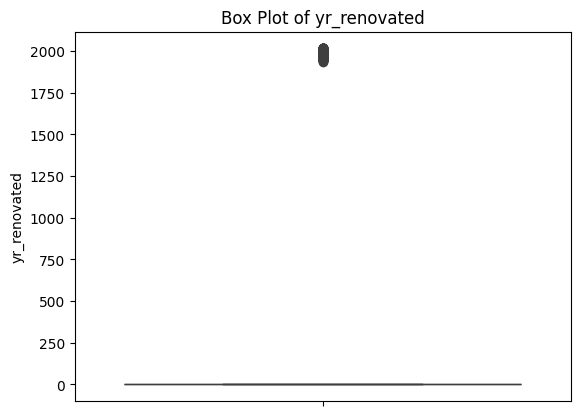

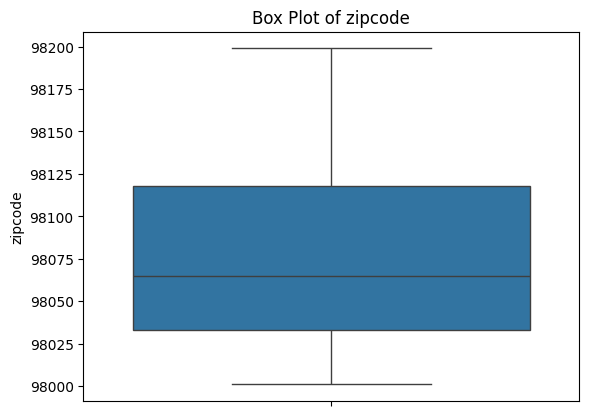

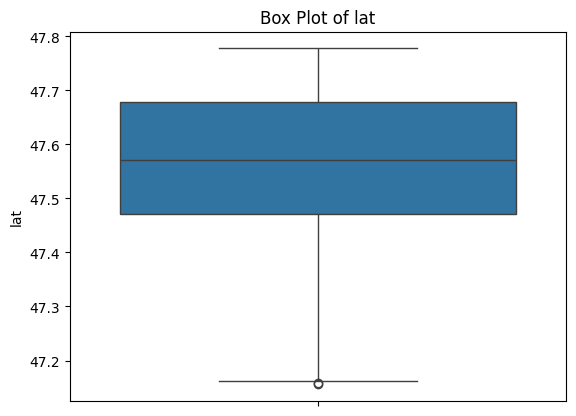

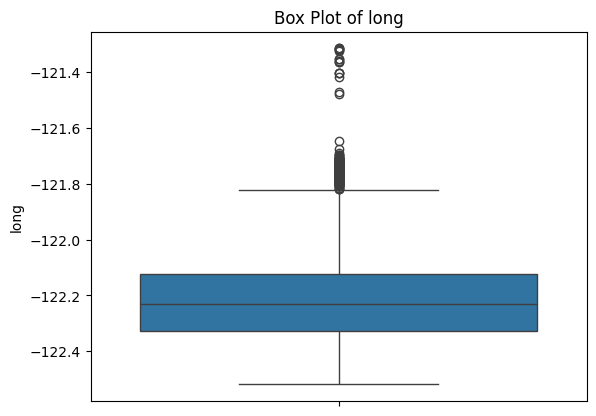

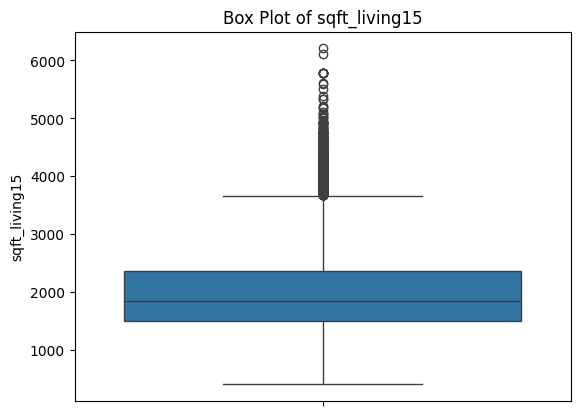

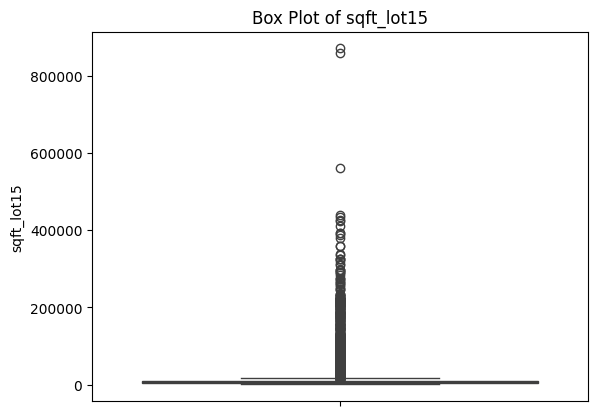

In [77]:
for col in data.columns:
  plt.figure()
  sns.boxplot(y=data[col])
  plt.title(f'Box Plot of {col}')
  plt.show()


# too much outliers need to be handled

In [78]:
outlier_indices = {}

for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (data[col] < lower) | (data[col] > upper)
    outlier_indices[col] = data[outlier_mask].index

outlier_indices

{'price': Index([    5,    21,    49,    69,   125,   153,   216,   246,   269,   270,
        ...
        21525, 21530, 21532, 21540, 21551, 21568, 21576, 21590, 21597, 21600],
       dtype='int64', length=1146),
 'bedrooms': Index([  154,   209,   232,   239,   264,   331,   350,   465,   486,   527,
        ...
        21186, 21226, 21240, 21326, 21332, 21375, 21443, 21519, 21522, 21552],
       dtype='int64', length=546),
 'bathrooms': Index([    5,    75,   235,   270,   300,   419,   450,   471,   509,   527,
        ...
        21506, 21514, 21520, 21530, 21532, 21551, 21561, 21576, 21593, 21600],
       dtype='int64', length=571),
 'sqft_living': Index([    5,    70,   115,   153,   239,   269,   270,   300,   313,   314,
        ...
        21521, 21525, 21530, 21532, 21540, 21551, 21561, 21576, 21590, 21600],
       dtype='int64', length=572),
 'sqft_lot': Index([    5,    12,    21,    36,    41,    49,    60,    69,    70,    74,
        ...
        21431, 21470, 21484, 214

In [79]:
for i in range(30):
  for col in data.columns:
      Q1 = data[col].quantile(0.25)
      Q3 = data[col].quantile(0.75)
      IQR = Q3 - Q1
      lower = Q1 - 1.5 * IQR
      upper = Q3 + 1.5 * IQR
      data.loc[data[col] < lower, col] = data[col].mean()
      data.loc[data[col] > upper, col] = data[col].mean()

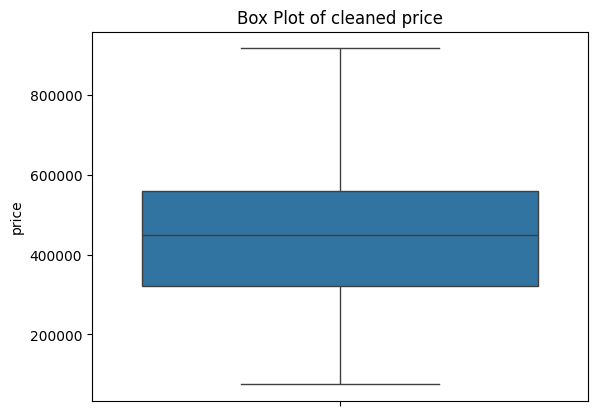

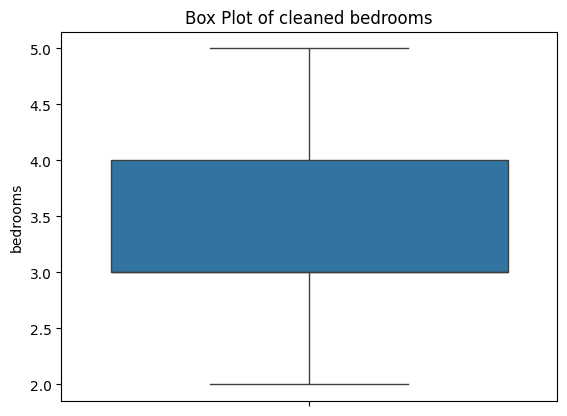

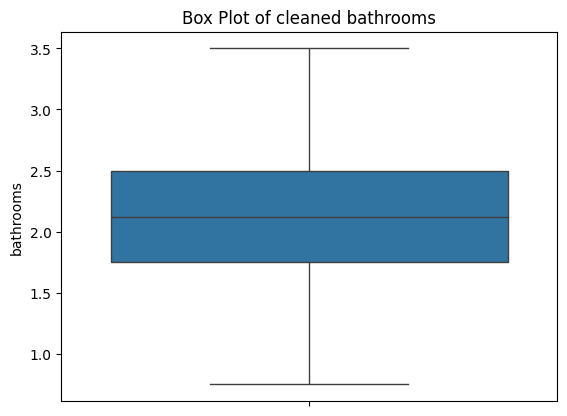

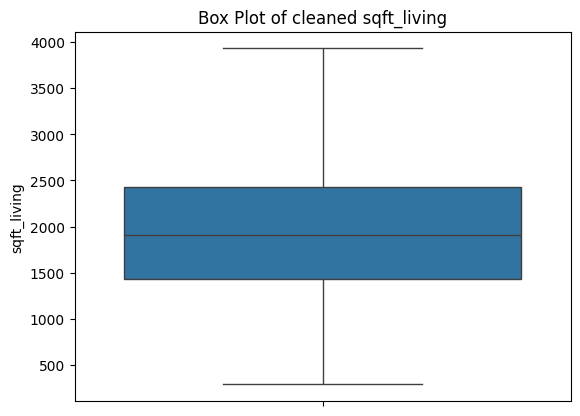

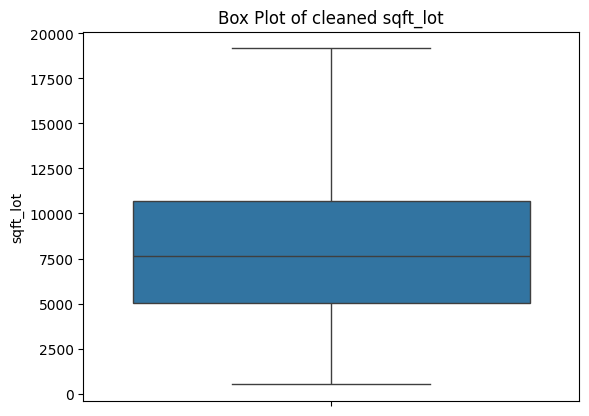

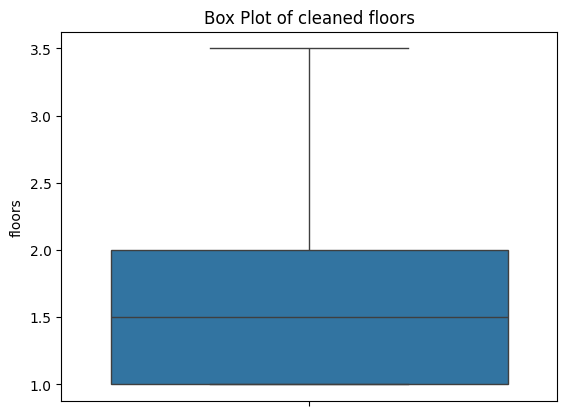

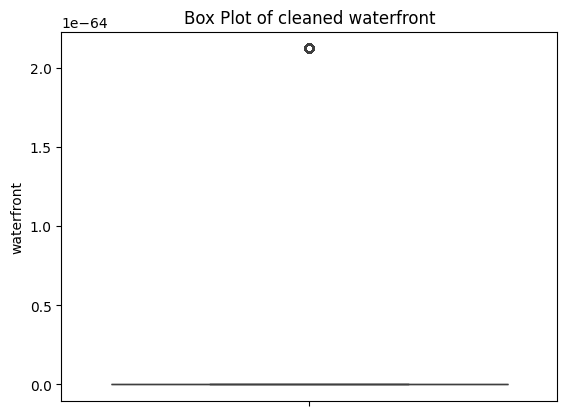

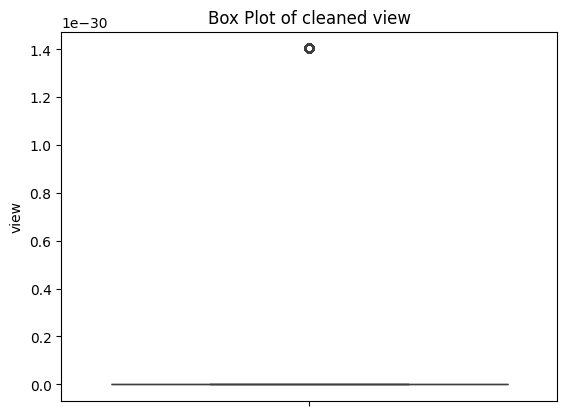

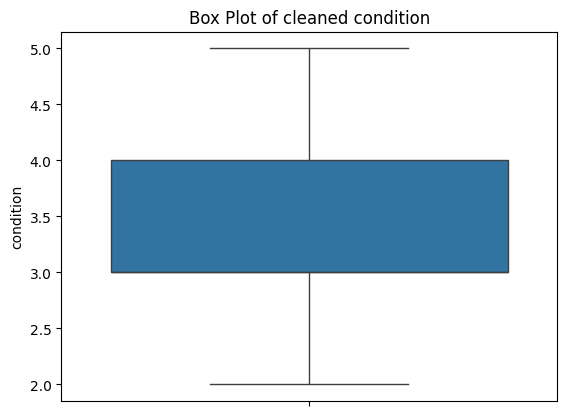

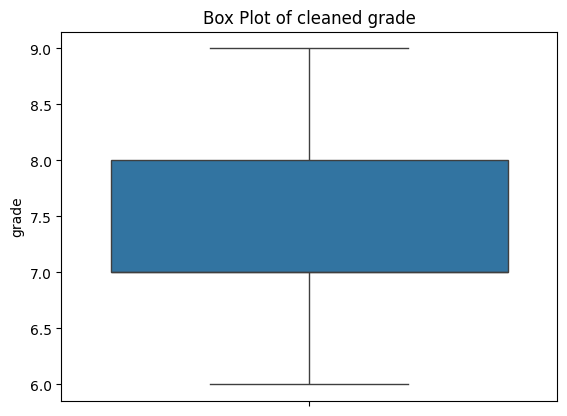

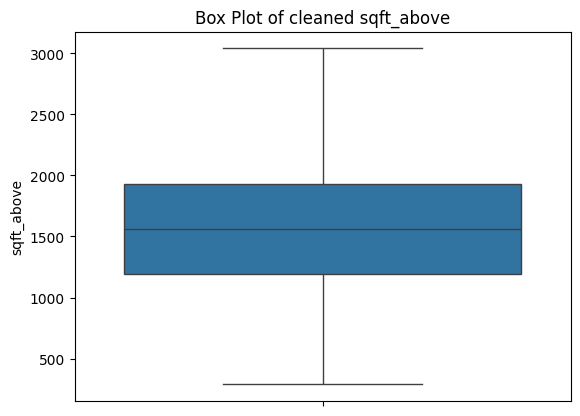

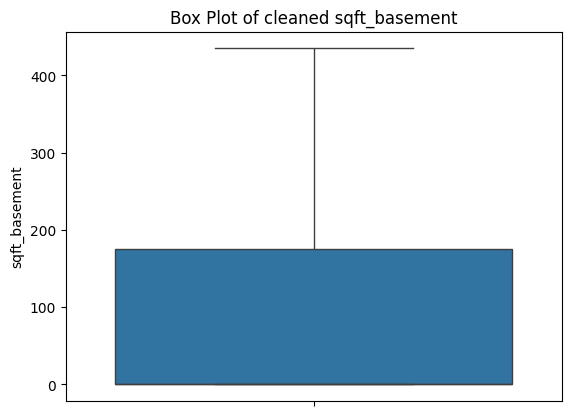

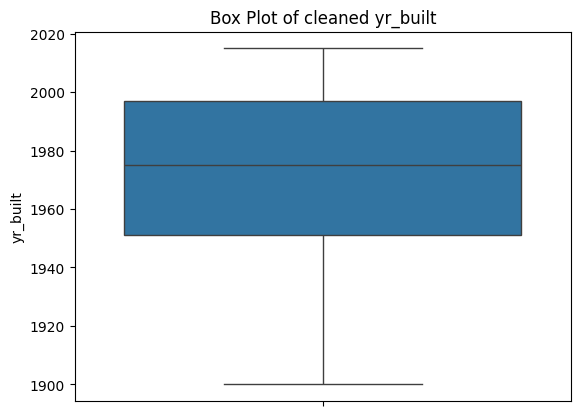

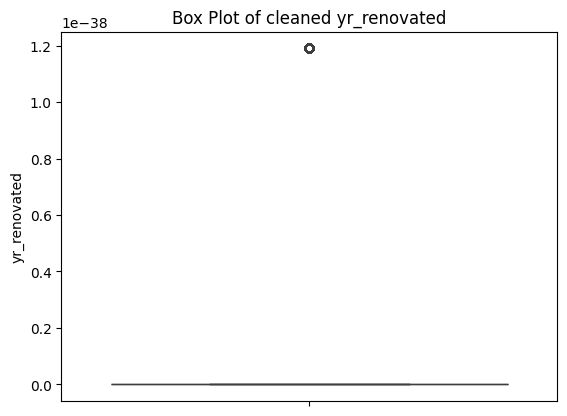

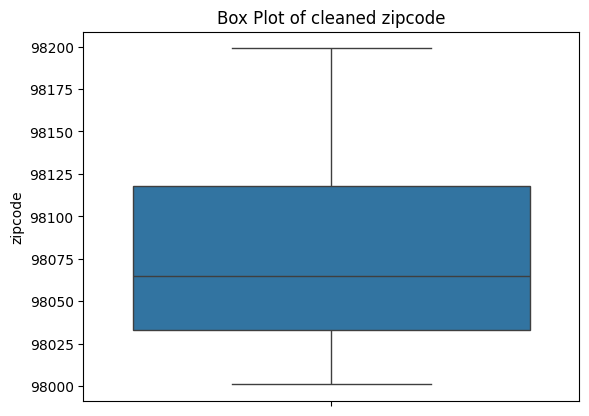

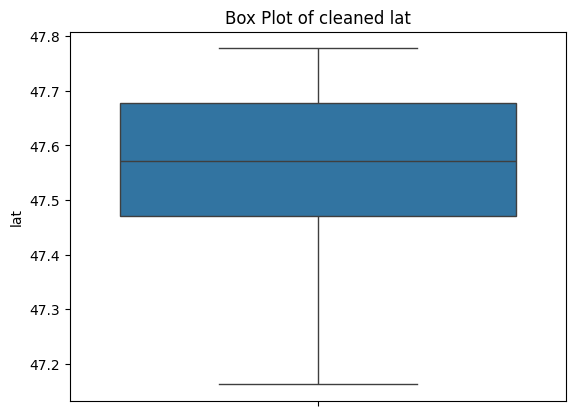

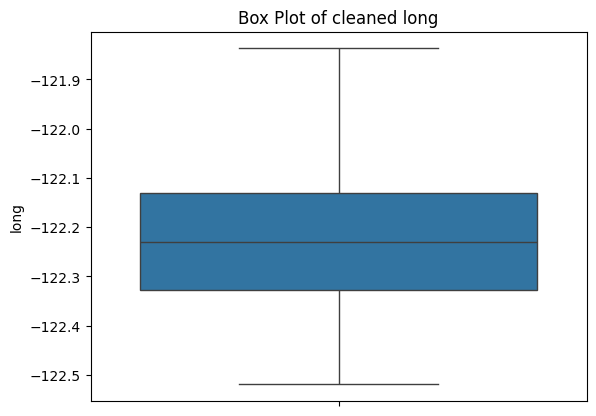

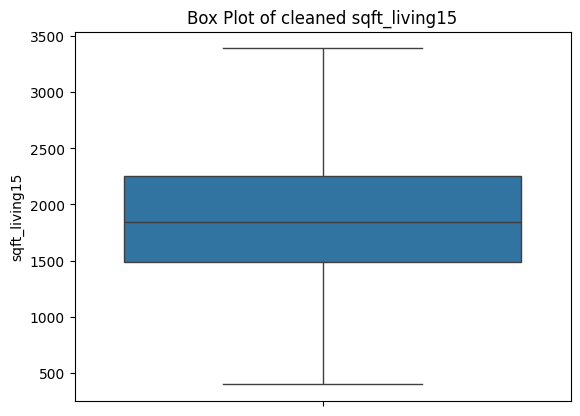

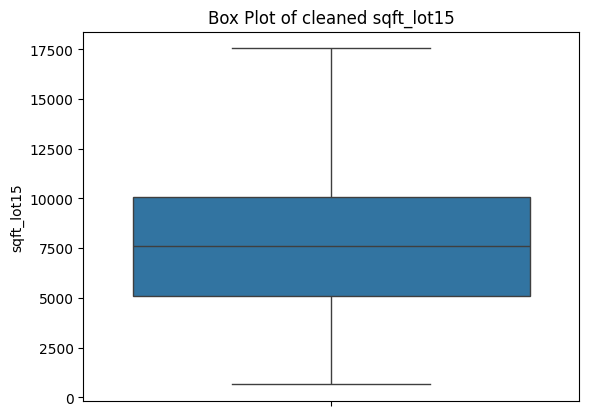

In [80]:
for col in data:
  plt.figure()
  sns.boxplot(y=data[col])
  plt.title(f'Box Plot of cleaned {col}')
  plt.show()

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21608 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21608 non-null  float64
 1   bedrooms       21608 non-null  float64
 2   bathrooms      21608 non-null  float64
 3   sqft_living    21608 non-null  float64
 4   sqft_lot       21608 non-null  float64
 5   floors         21608 non-null  float64
 6   waterfront     21608 non-null  float64
 7   view           21608 non-null  float64
 8   condition      21608 non-null  float64
 9   grade          21608 non-null  float64
 10  sqft_above     21608 non-null  float64
 11  sqft_basement  21608 non-null  float64
 12  yr_built       21608 non-null  float64
 13  yr_renovated   21608 non-null  float64
 14  zipcode        21608 non-null  float64
 15  lat            21608 non-null  float64
 16  long           21608 non-null  float64
 17  sqft_living15  21608 non-null  float64
 18  sqft_lot15 

In [82]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,2.160800e+04,2.160800e+04,21608.000000,21608.000000,21608.000000,21608.000000,21608.000000,2.160800e+04,21608.000000,21608.000000,21608.00000,21608.000000,21608.000000
mean,460679.549467,3.348690,2.060520,1974.110688,8252.017212,1.494146,1.602375e-66,1.379382e-31,3.412823,7.488946,1617.395352,79.699446,1970.999907,5.031171e-40,98077.942614,47.560087,-122.21993,1905.811093,7812.676356
std,175320.823429,0.790383,0.677134,720.581885,4195.105620,0.539910,1.837991e-65,4.178974e-31,0.644551,0.813207,554.049094,111.909773,29.371463,2.395391e-39,53.506883,0.138524,0.12969,551.498231,3482.193499
min,75000.000000,2.000000,0.750000,290.000000,520.000000,1.000000,0.000000e+00,0.000000e+00,2.000000,6.000000,290.000000,0.000000,1900.000000,0.000000e+00,98001.000000,47.162200,-122.51900,399.000000,651.000000
25%,321837.500000,3.000000,1.750000,1429.250000,5040.000000,1.000000,0.000000e+00,0.000000e+00,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000e+00,98033.000000,47.471075,-122.32800,1490.000000,5100.000000
50%,450000.000000,3.000000,2.116015,1910.000000,7620.000000,1.500000,0.000000e+00,0.000000e+00,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000e+00,98065.000000,47.571800,-122.23050,1840.000000,7620.000000
75%,560000.000000,4.000000,2.500000,2430.000000,10690.500000,2.000000,0.000000e+00,0.000000e+00,4.000000,8.000000,1930.000000,175.311315,1997.000000,0.000000e+00,98118.000000,47.678000,-122.13100,2250.000000,10083.250000
max,917000.000000,5.000000,3.500000,3931.000000,19163.000000,3.500000,2.124178e-64,1.403942e-30,5.000000,9.000000,3040.000000,435.000000,2015.000000,1.190729e-38,98199.000000,47.777600,-121.83700,3390.000000,17550.000000


In [83]:
data.duplicated().sum()

np.int64(6)

In [84]:
data.drop_duplicates(inplace=True)

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21602 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21602 non-null  float64
 1   bedrooms       21602 non-null  float64
 2   bathrooms      21602 non-null  float64
 3   sqft_living    21602 non-null  float64
 4   sqft_lot       21602 non-null  float64
 5   floors         21602 non-null  float64
 6   waterfront     21602 non-null  float64
 7   view           21602 non-null  float64
 8   condition      21602 non-null  float64
 9   grade          21602 non-null  float64
 10  sqft_above     21602 non-null  float64
 11  sqft_basement  21602 non-null  float64
 12  yr_built       21602 non-null  float64
 13  yr_renovated   21602 non-null  float64
 14  zipcode        21602 non-null  float64
 15  lat            21602 non-null  float64
 16  long           21602 non-null  float64
 17  sqft_living15  21602 non-null  float64
 18  sqft_lot15 

In [86]:
features = data.drop(columns=['price'])
target = data[['price']]

In [87]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [88]:
# rs = RobustScaler()

# x_train = pd.DataFrame(rs.fit_transform(x_train),
#                        columns=x_train.columns)
# x_test = pd.DataFrame(rs.transform(x_test),
#                       columns=x_test.columns)

# y_train = pd.DataFrame(rs.fit_transform(y_train),
#                        columns=y_train.columns)
# y_test = pd.DataFrame(rs.transform(y_test),
#                       columns=y_test.columns)


MMScaler = MinMaxScaler()


x_train = pd.DataFrame(MMScaler.fit_transform(x_train),
                       columns=x_train.columns)
x_test = pd.DataFrame(MMScaler.transform(x_test),
                      columns=x_test.columns)

y_train = pd.DataFrame(MMScaler.fit_transform(y_train),
                       columns=y_train.columns)
y_test = pd.DataFrame(MMScaler.transform(y_test),
                      columns=y_test.columns)

In [89]:
x_train.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0.333333,0.363636,0.275204,0.497398,0.0,0.0,0.0,0.666667,0.333333,0.367041,0.000000,0.591304,0.0,0.106061,0.054495,0.757709,0.431628,0.439612
1,0.000000,0.090909,0.193766,0.540686,0.2,0.0,0.0,0.333333,0.000000,0.258427,0.000000,0.591304,0.0,0.323232,0.608256,0.448026,0.388164,0.717149
2,0.333333,0.636364,0.359450,0.725956,0.0,0.0,0.0,0.666667,0.333333,0.284644,0.228687,0.747826,0.0,0.131313,0.517866,0.737151,0.515212,0.717149
3,0.333333,0.545455,0.325751,0.326128,0.0,0.0,0.0,0.666667,0.333333,0.325843,0.666667,0.591304,0.0,0.272727,0.485071,0.486050,0.368104,0.417125
4,0.000000,0.454545,0.275204,0.181301,0.0,0.0,0.0,0.333333,0.666667,0.367041,0.000000,0.895652,0.0,0.262626,0.888726,0.718062,0.348044,0.192260


In [90]:
lr = LinearRegression()

In [91]:
lr.fit(x_train, y_train)

LinearRegression()

In [92]:
y_pred = lr.predict(x_test)

In [93]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.01914693251211093
RMSE: 0.13837244130285095
MAE : 0.10601217550671076
R²  : 0.5543858320529655


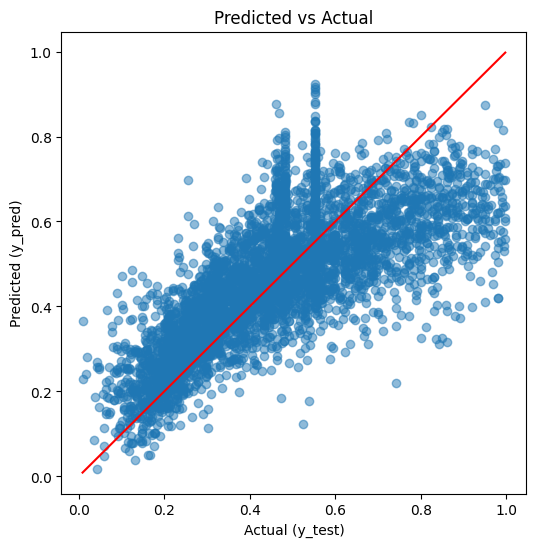

In [94]:
y_test_flat = y_test.to_numpy().ravel()
y_pred_flat = y_pred.ravel()

plt.figure(figsize=(6,6))
plt.scatter(y_test_flat, y_pred_flat, alpha=0.5)

lims = [min(y_test_flat.min(), y_pred_flat.min()),
        max(y_test_flat.max(), y_pred_flat.max())]

plt.plot(lims, lims, color="red")

plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Predicted vs Actual")
plt.show()